In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline



train_path = "/content/drive/MyDrive/work_2025/Feature Engineering/TrainDataset2025.xls"
df = pd.read_excel(train_path, engine="xlrd")

print("Shape of raw train data:", df.shape)
print(df.dtypes.head())



Shape of raw train data: (400, 121)
ID                                object
pCR (outcome)                      int64
RelapseFreeSurvival (outcome)    float64
Age                              float64
ER                                 int64
dtype: object


In [21]:
import pandas as pd

print(df.columns.tolist())

['ID', 'pCR (outcome)', 'RelapseFreeSurvival (outcome)', 'Age', 'ER', 'PgR', 'HER2', 'TrippleNegative', 'ChemoGrade', 'Proliferation', 'HistologyType', 'LNStatus', 'TumourStage', 'Gene', 'original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn', 'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice', 'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength', 'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean', 'original_firstorder_Median', '

In [25]:
df = df.copy()
df.replace(999, np.nan, inplace=True)
df.replace(999.0, np.nan, inplace=True)


missing_frac = df.isna().mean().sort_values(ascending=False)
print("Top 20 columns by missing fraction:")
print(missing_frac.head(20))

num_df = df.select_dtypes(include=["int64", "float64"])
print(num_df.describe().T)

Top 20 columns by missing fraction:
Gene                                      0.2200
pCR (outcome)                             0.0125
ChemoGrade                                0.0075
HistologyType                             0.0075
Proliferation                             0.0050
LNStatus                                  0.0025
TrippleNegative                           0.0025
PgR                                       0.0025
HER2                                      0.0025
Age                                       0.0000
RelapseFreeSurvival (outcome)             0.0000
ER                                        0.0000
ID                                        0.0000
TumourStage                               0.0000
original_shape_Elongation                 0.0000
original_shape_Flatness                   0.0000
original_shape_LeastAxisLength            0.0000
original_shape_MajorAxisLength            0.0000
original_shape_Maximum2DDiameterColumn    0.0000
original_shape_Maximum2DDiameterR

/tmp/ipython-input-2357890819.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


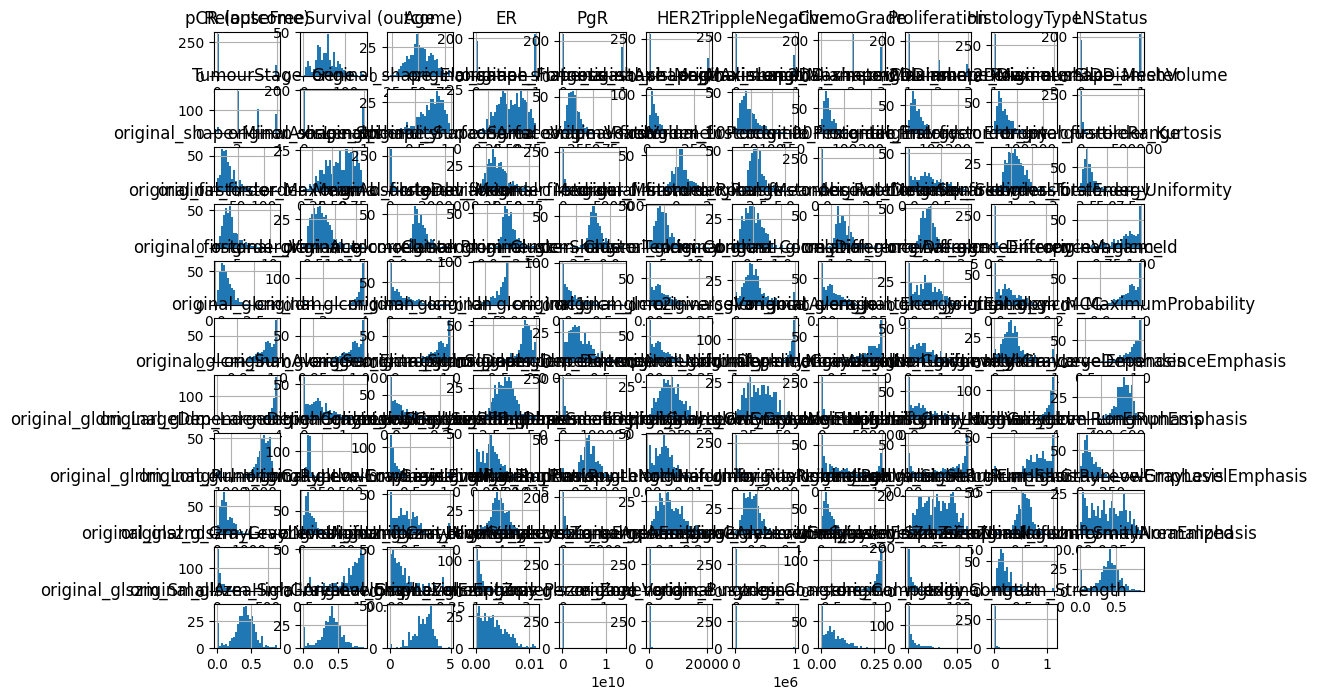

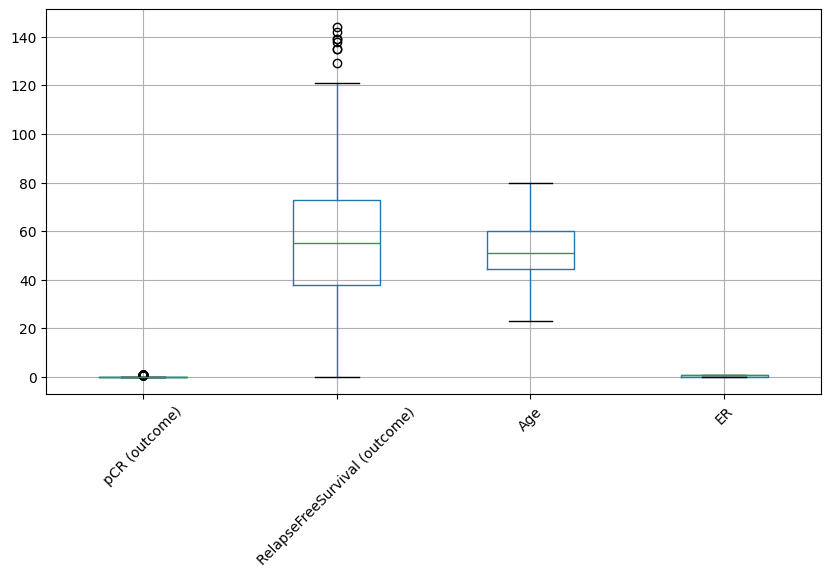

In [4]:
import matplotlib.pyplot as plt

num_df.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

sample_num_cols = num_df.columns[:4]
num_df[sample_num_cols].boxplot(figsize=(10, 5))
plt.xticks(rotation=45)
plt.show()


In [15]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(len(num_cols), "numeric columns")


120 numeric columns


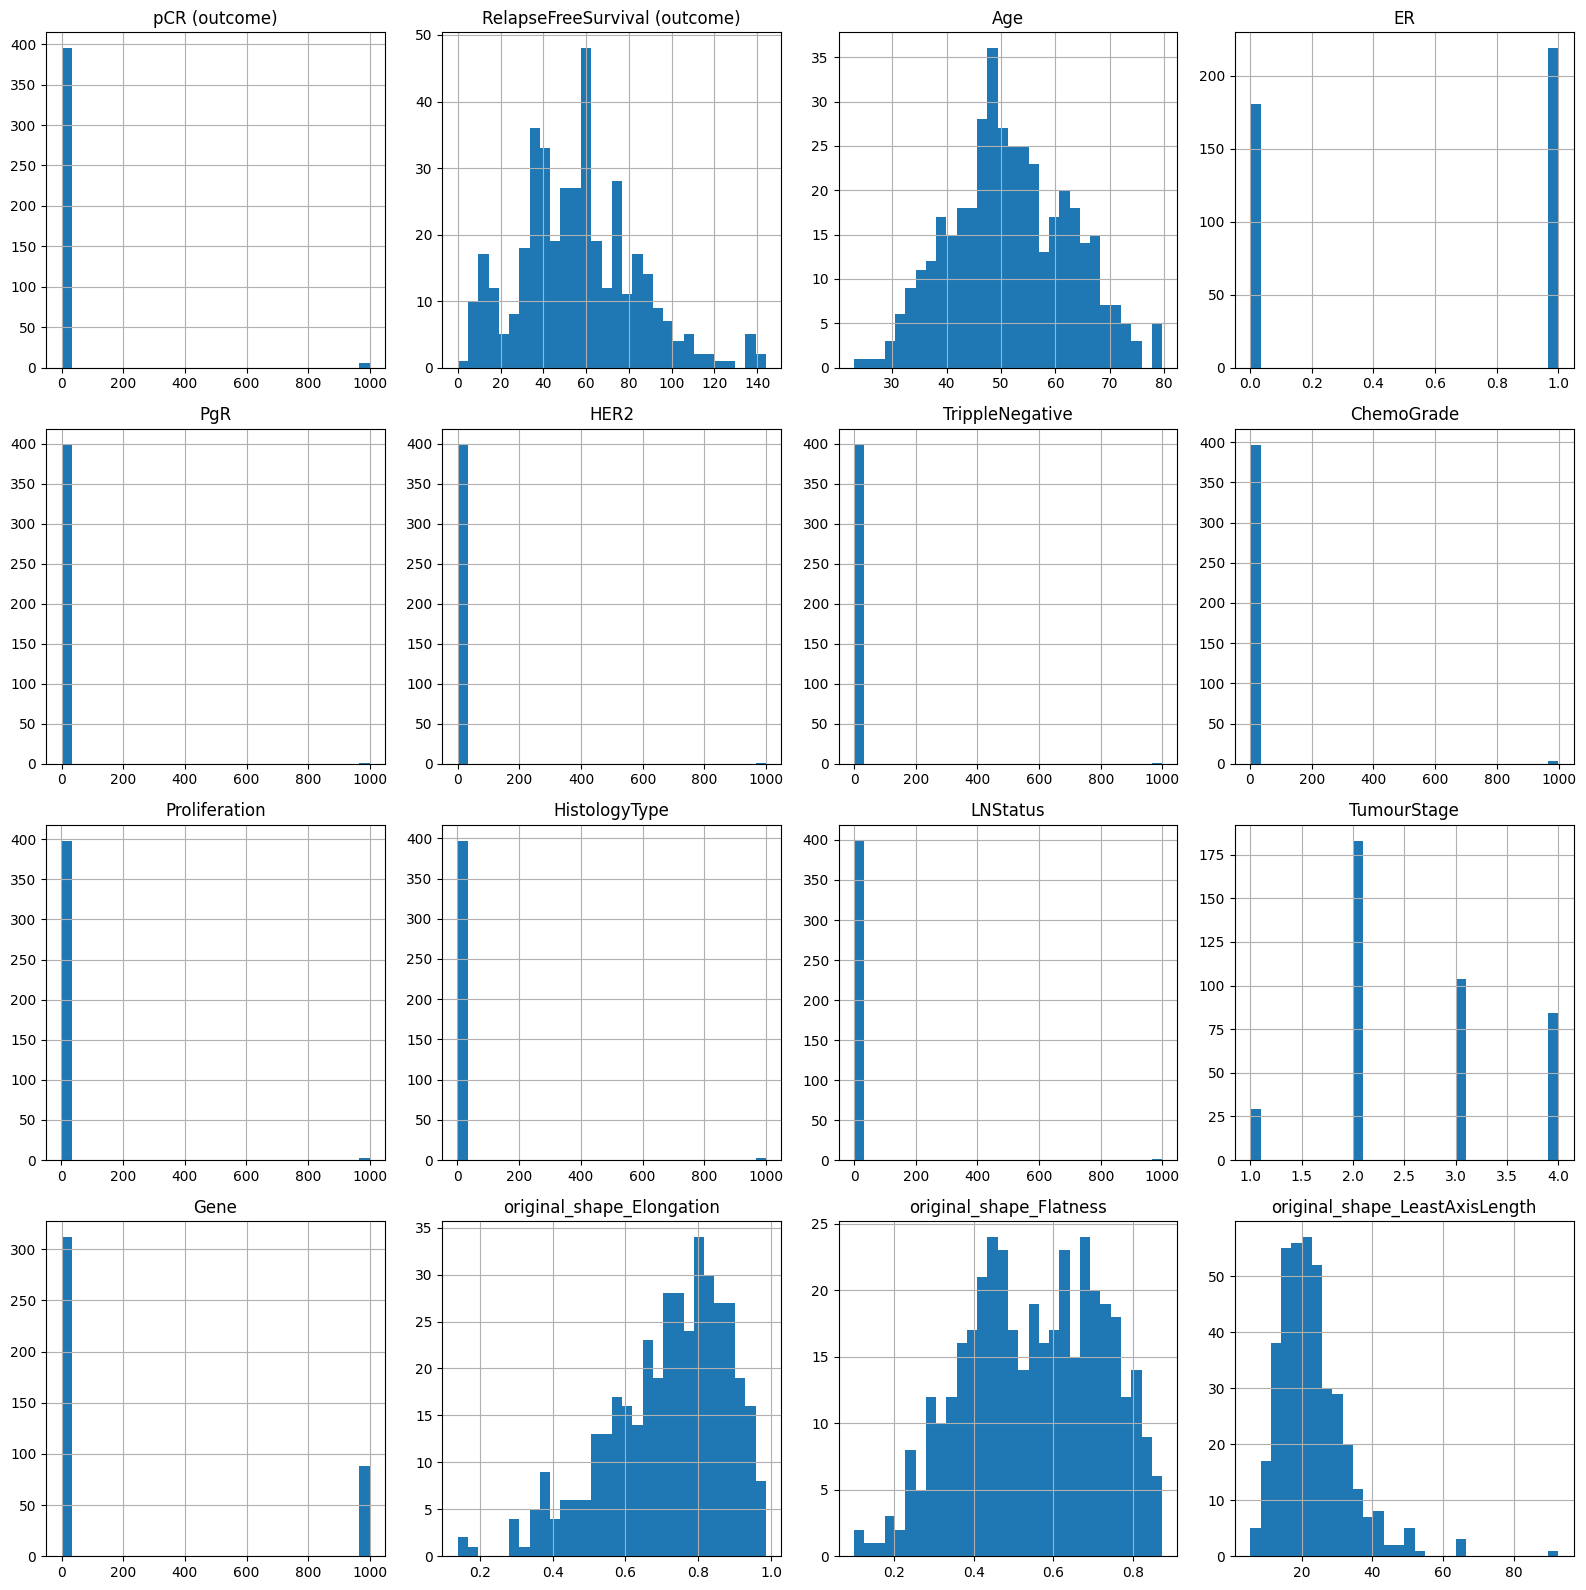

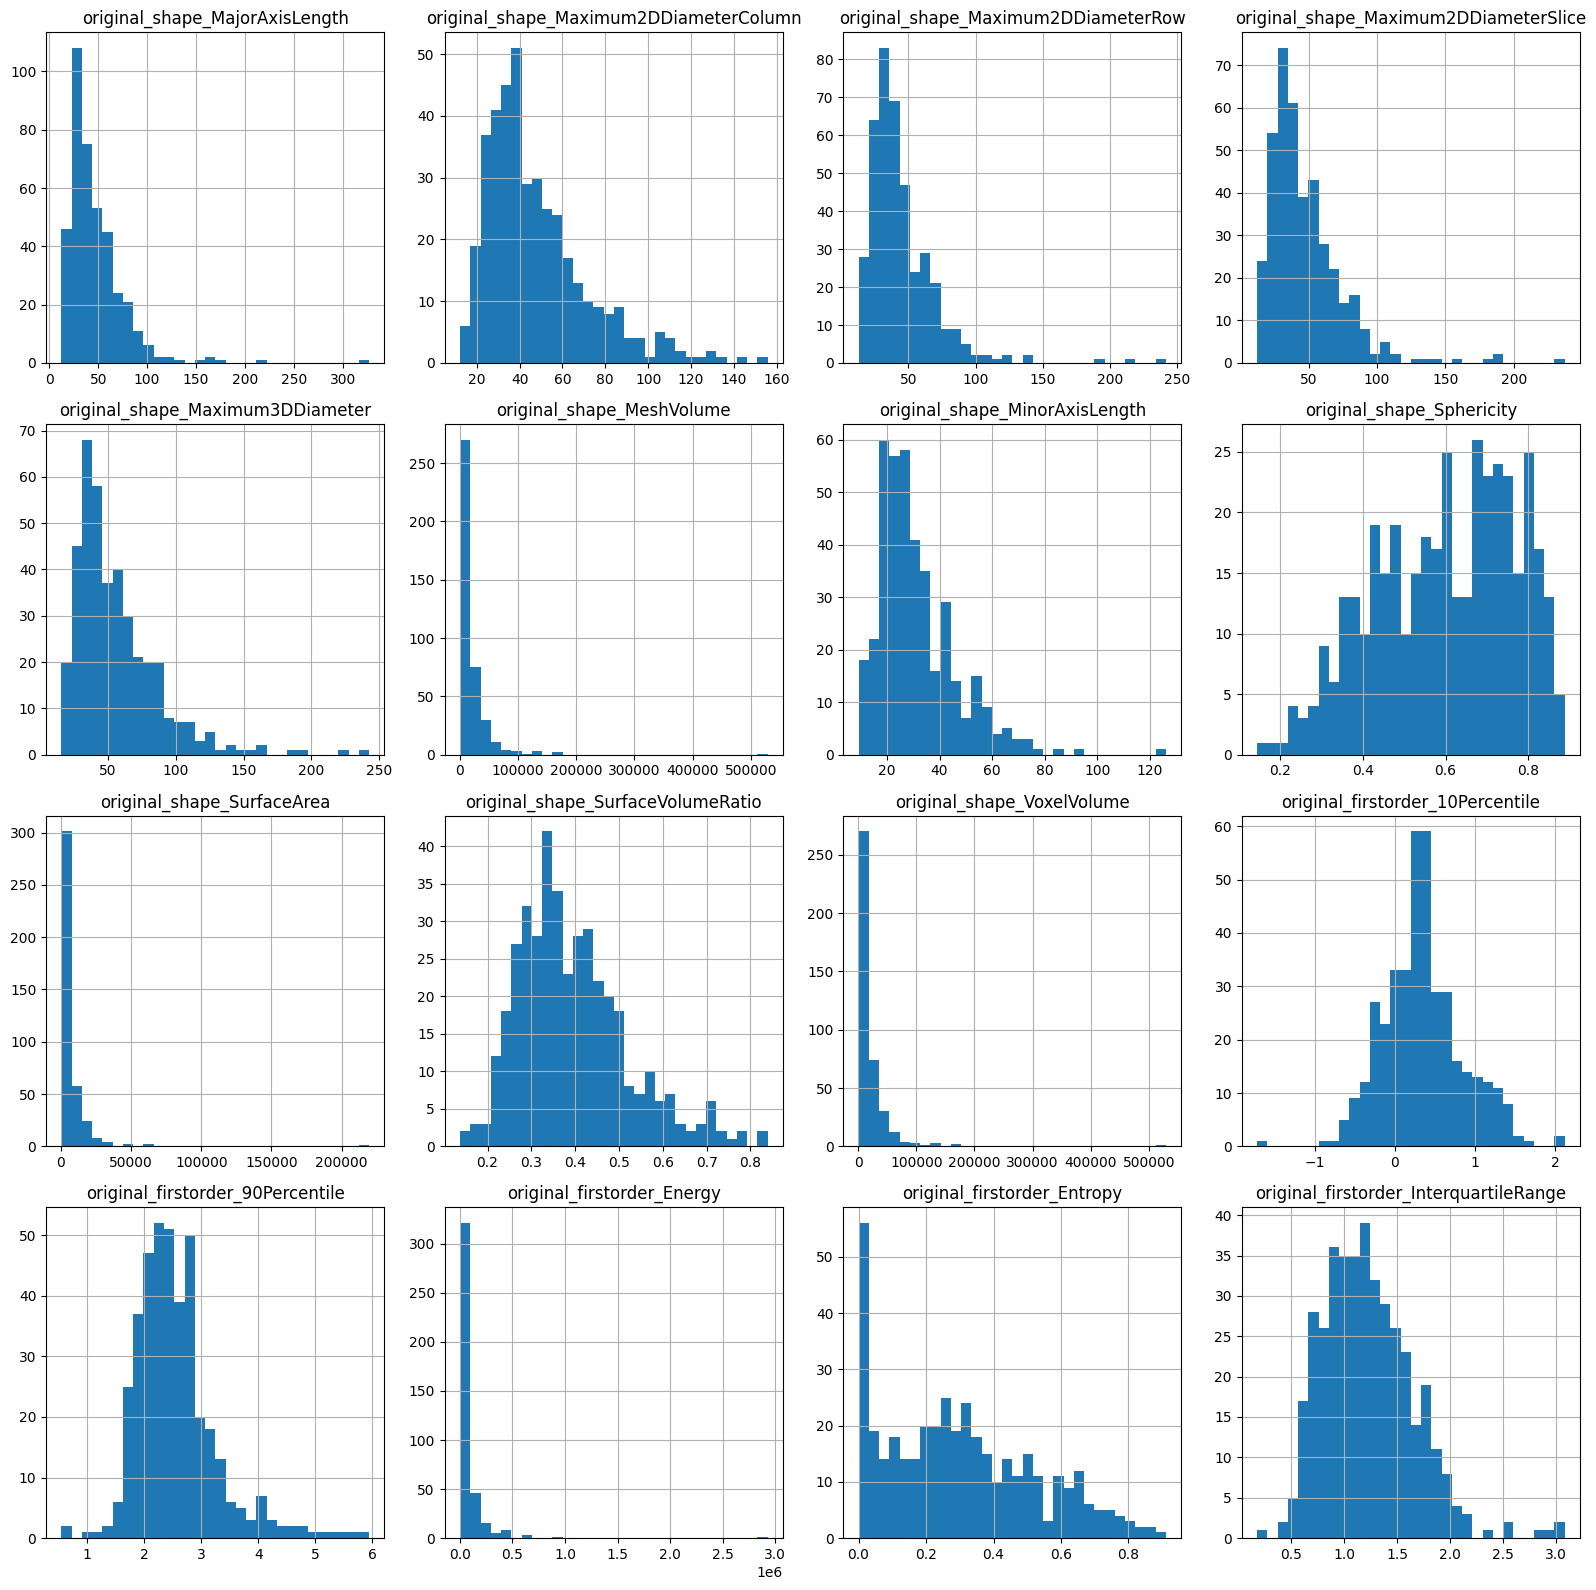

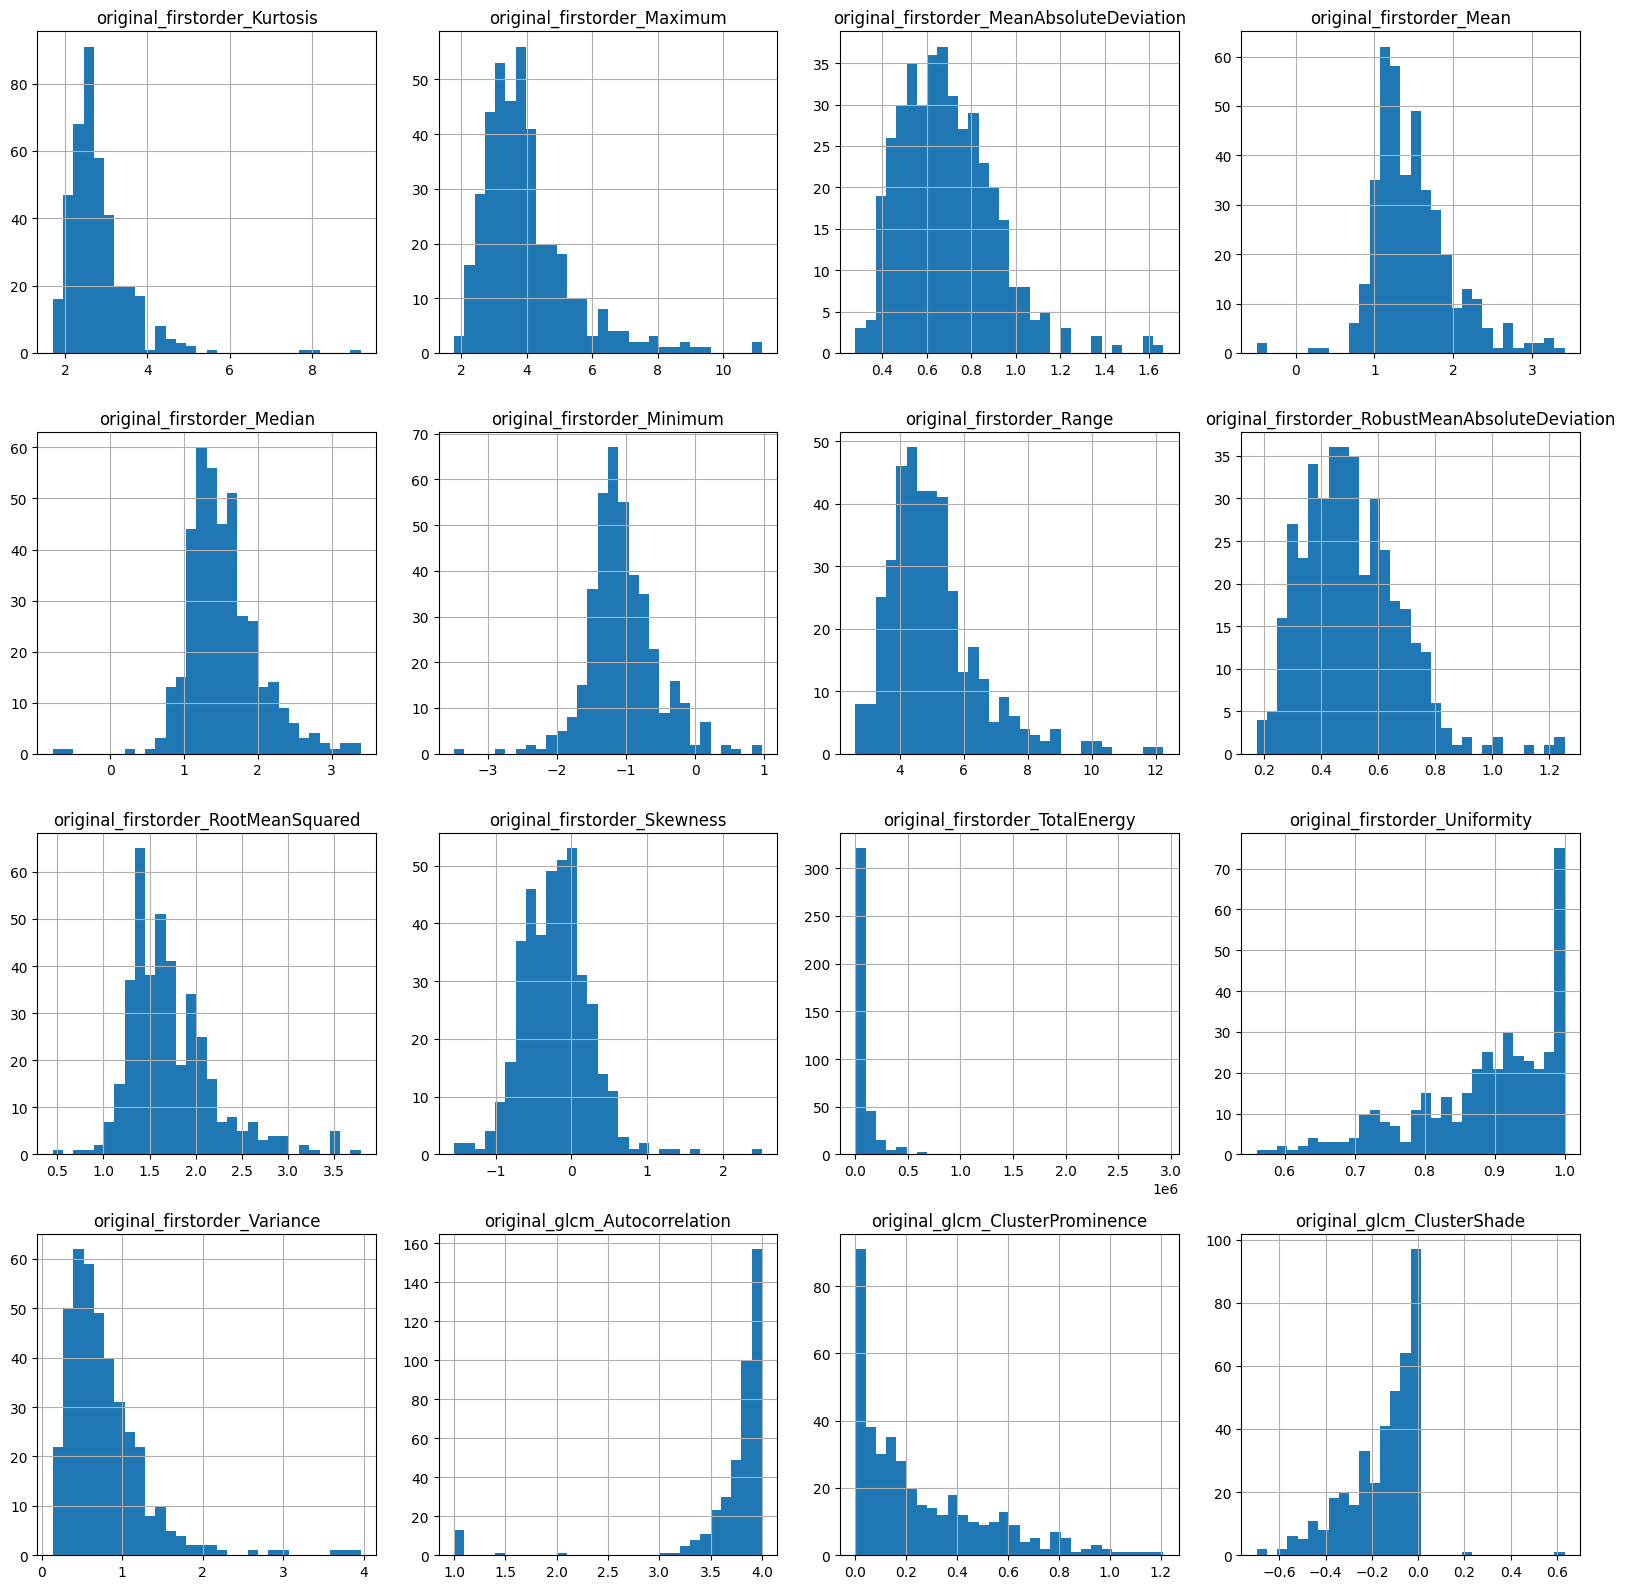

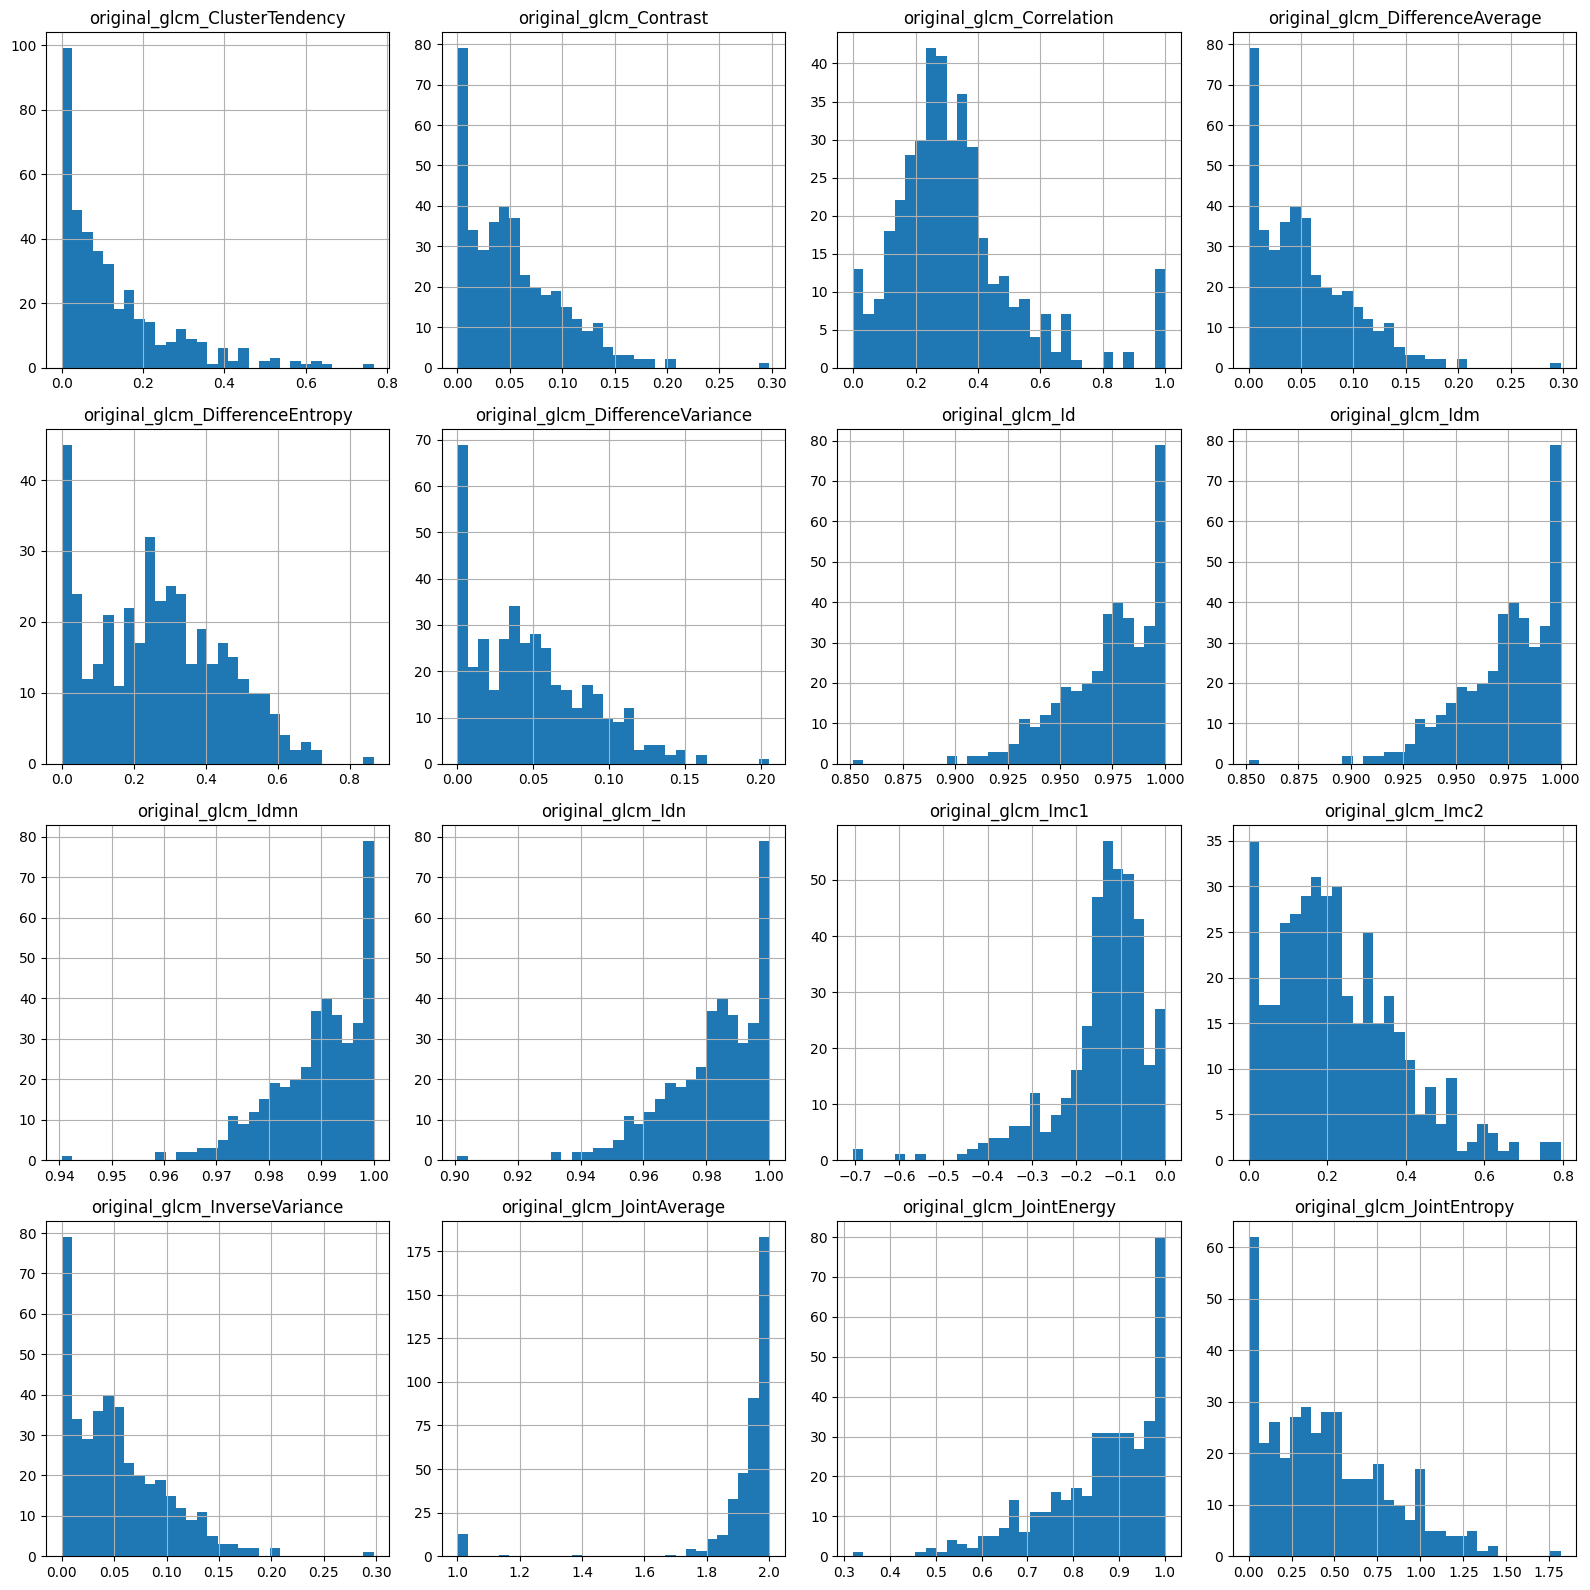

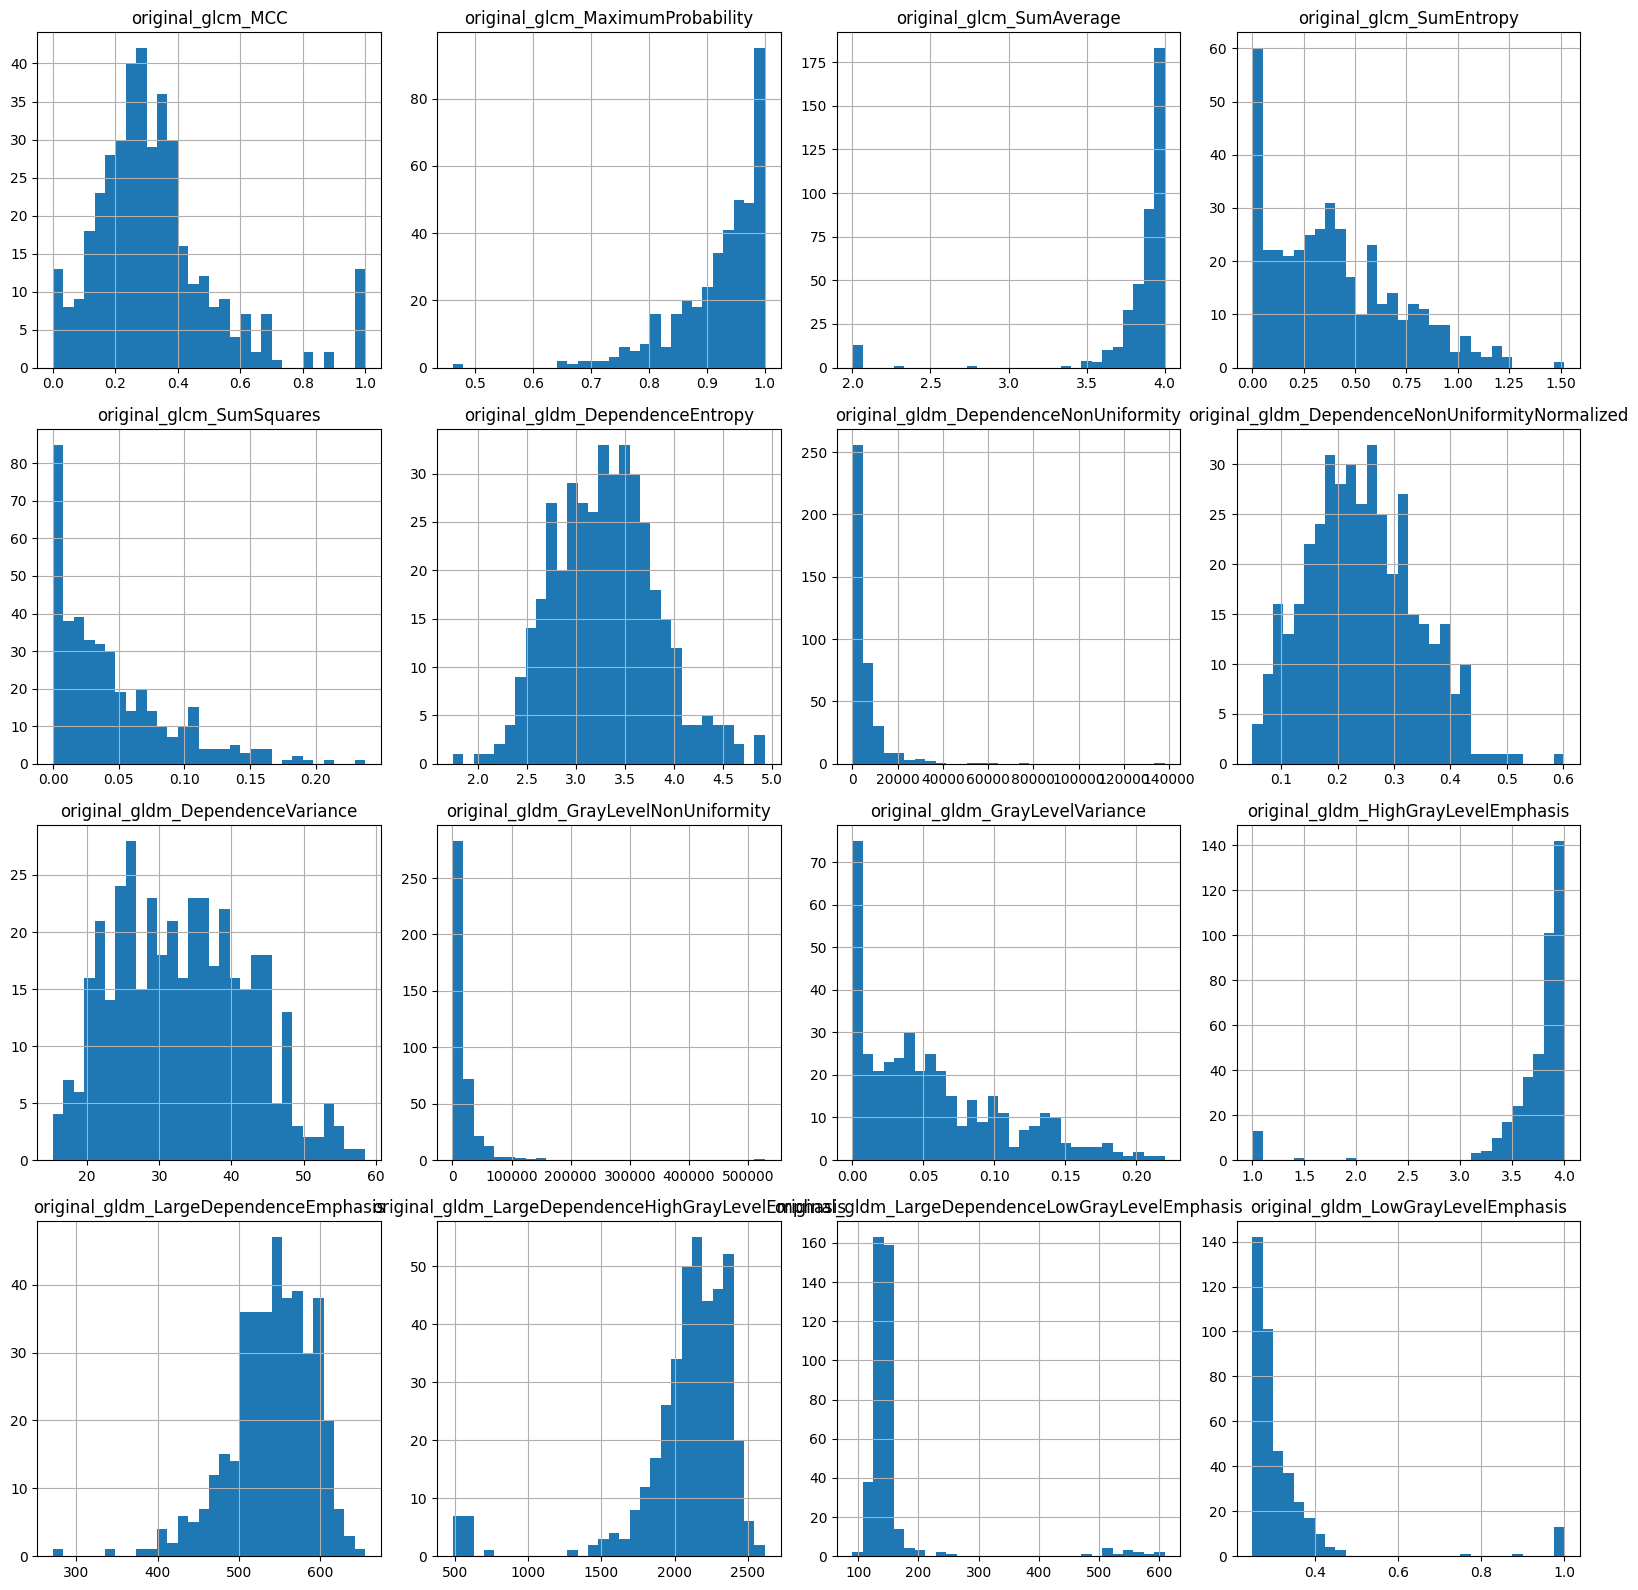

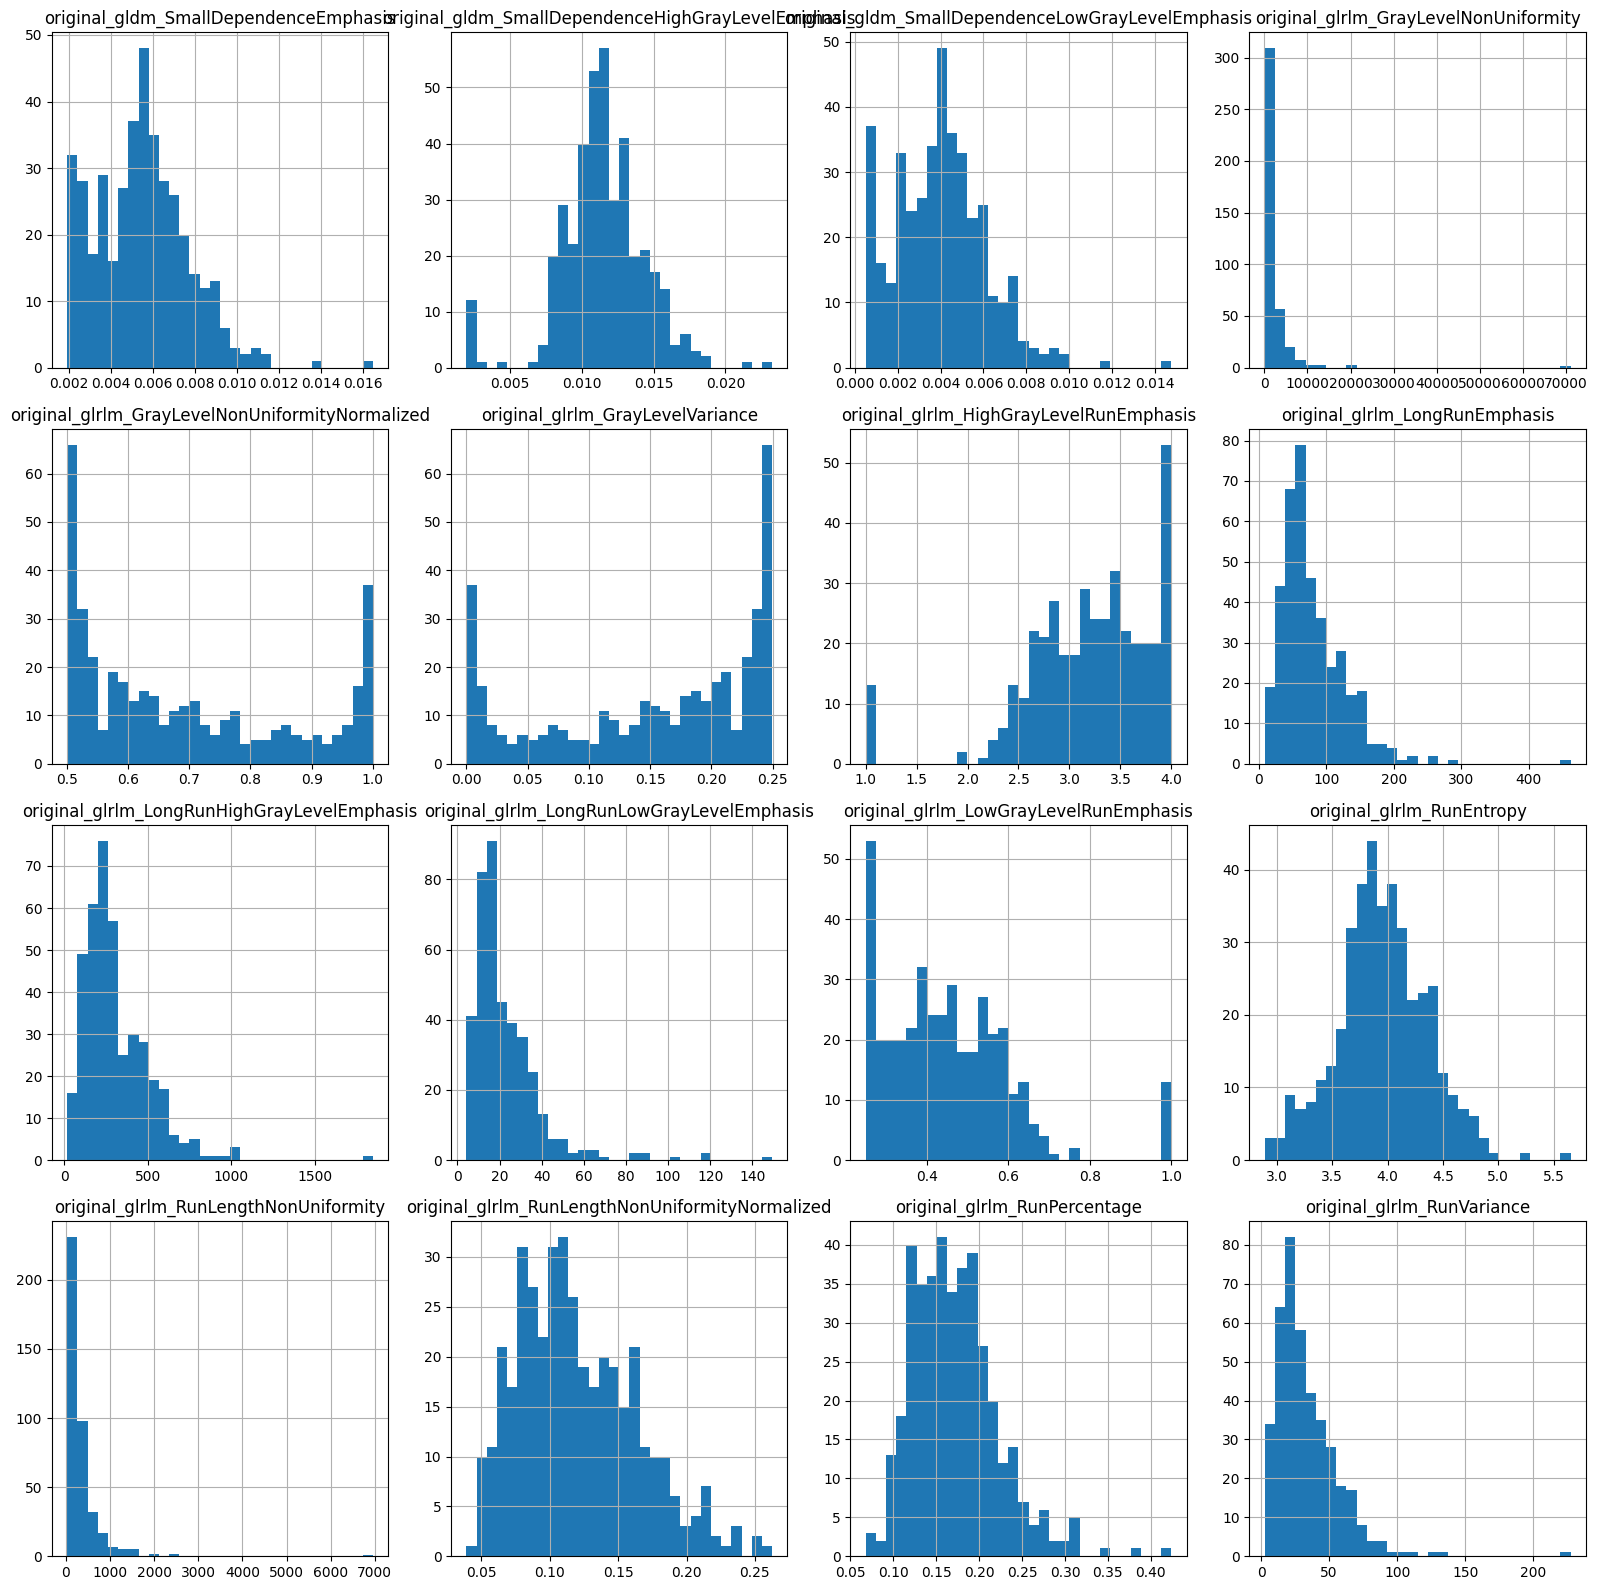

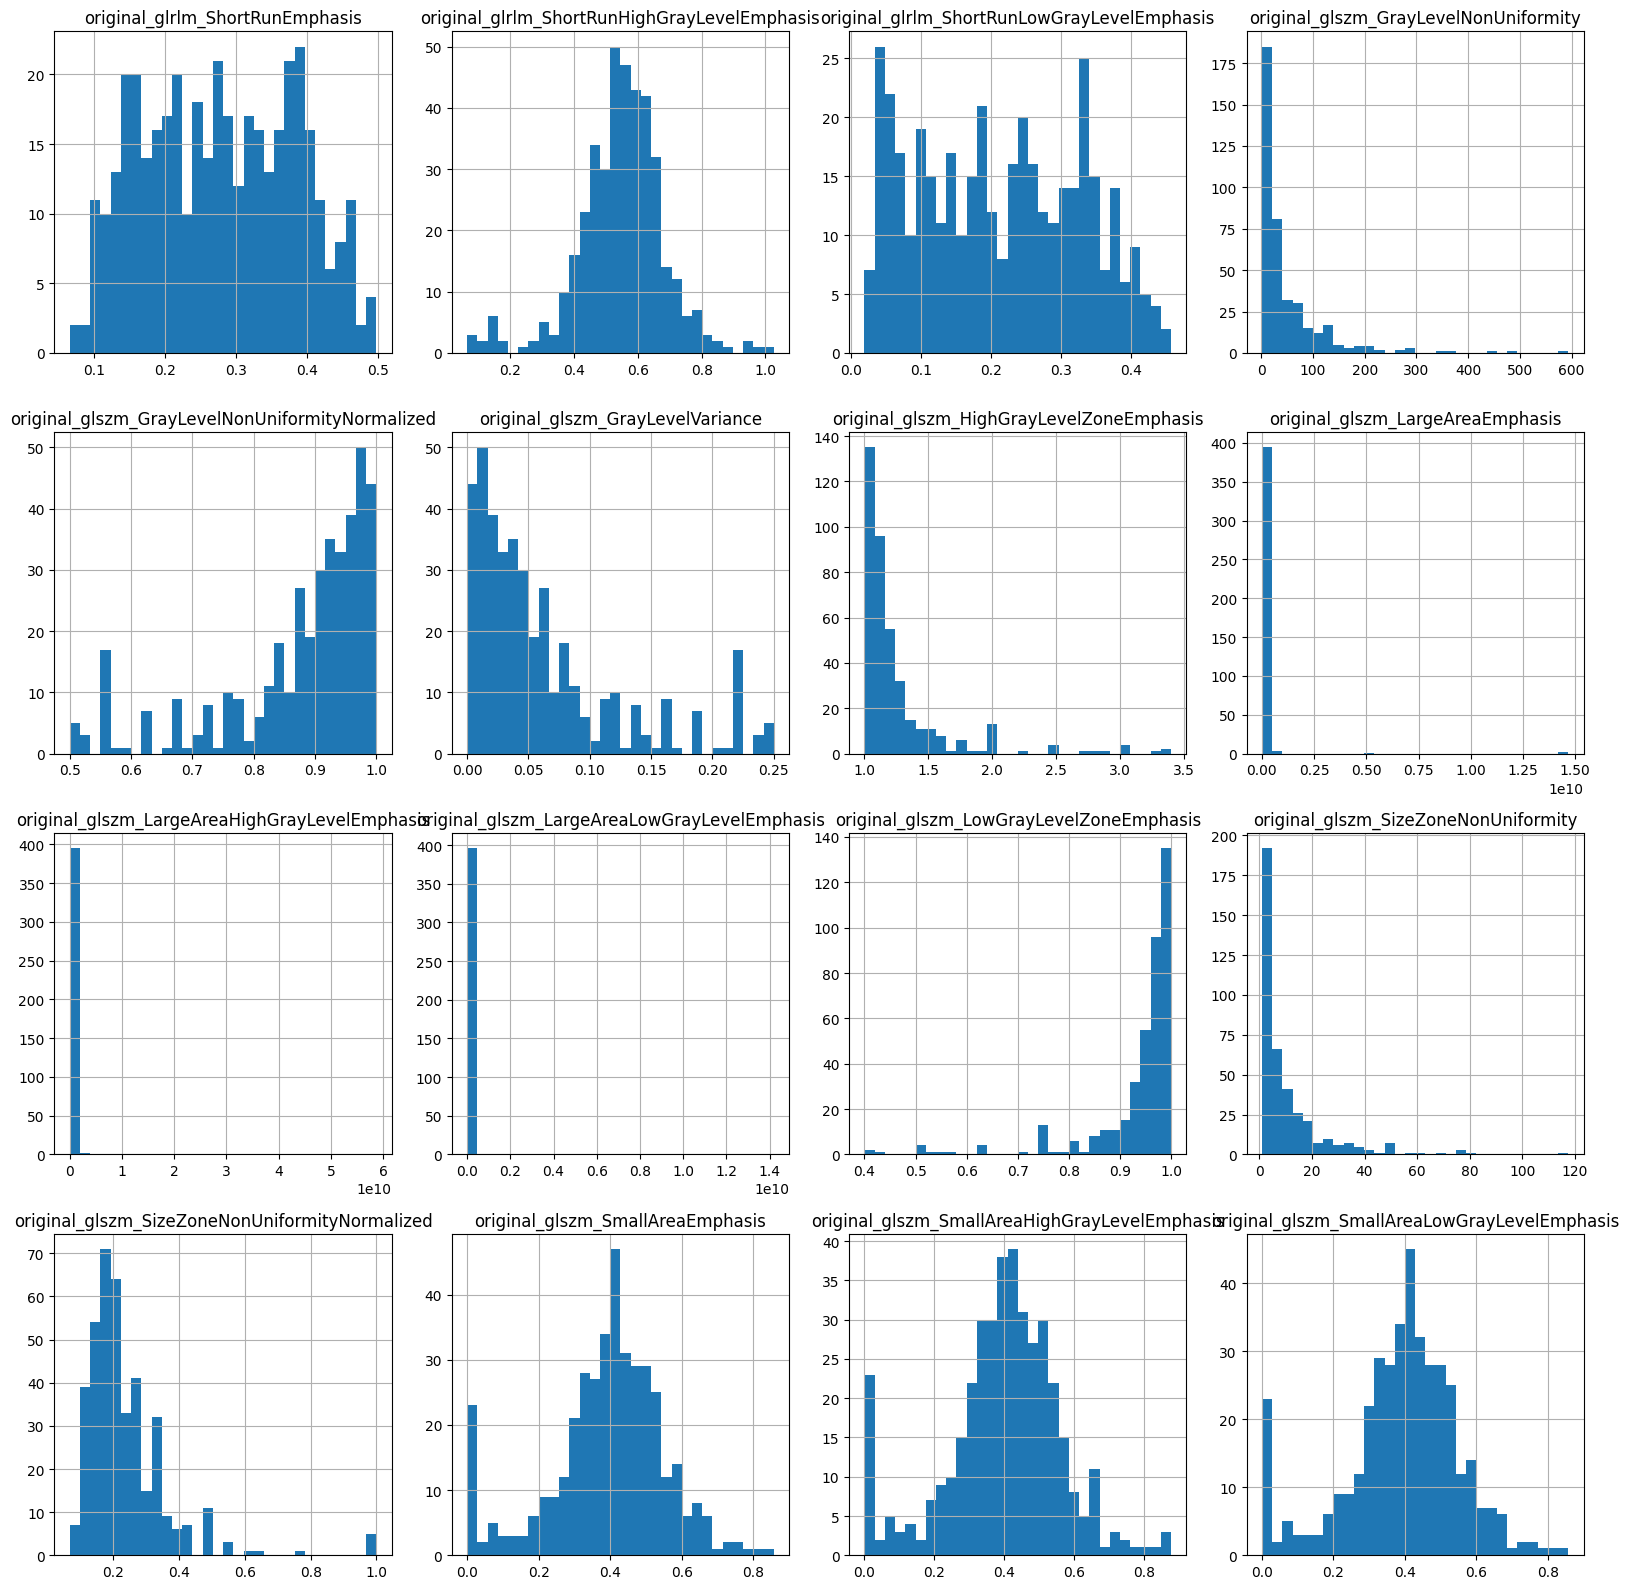

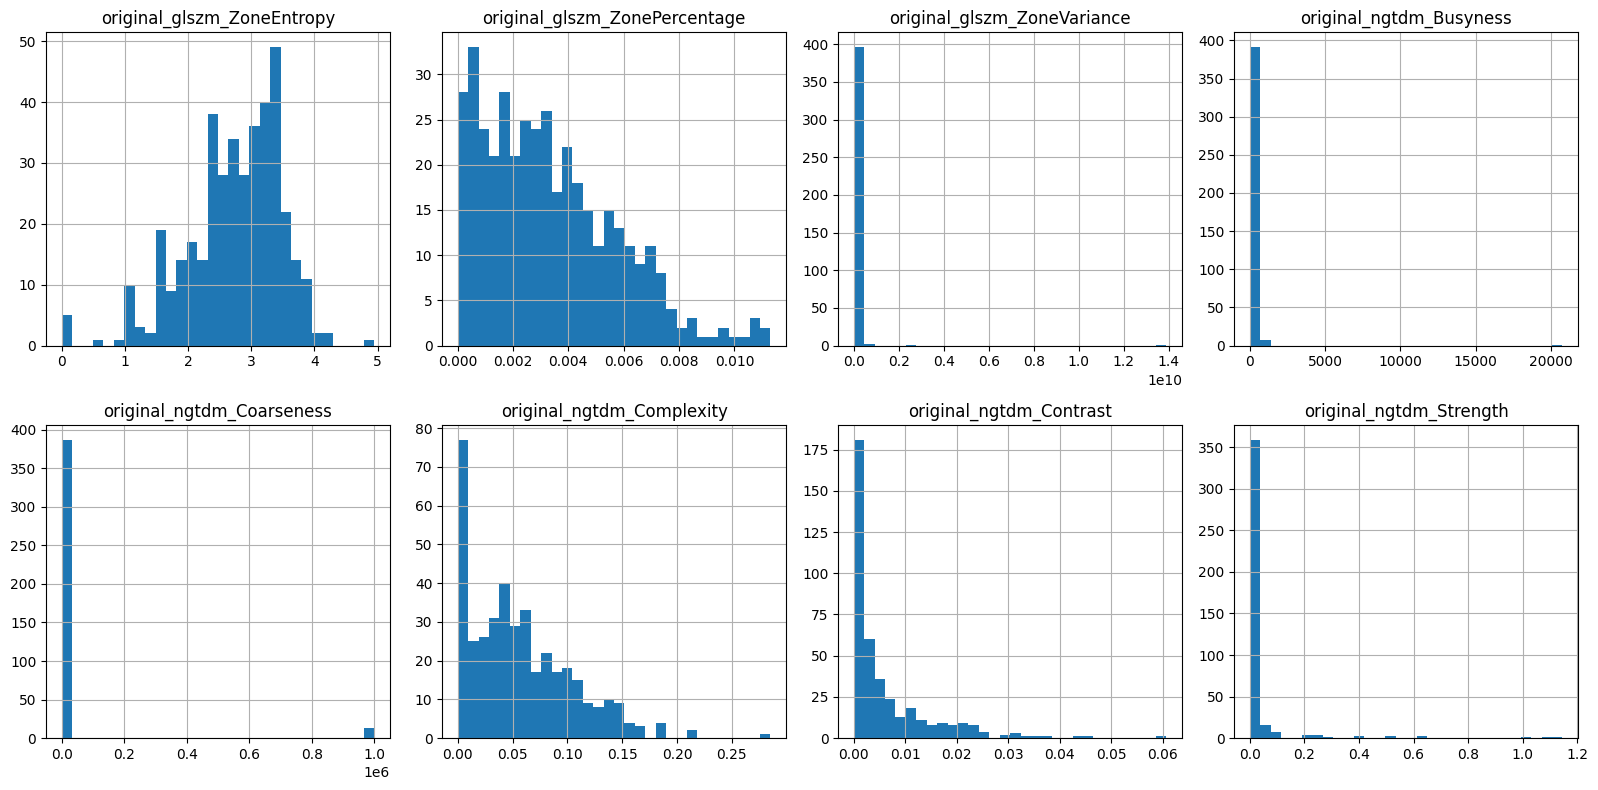

In [16]:
import math

cols_per_fig = 16
bins = 30

for start in range(0, len(num_cols), cols_per_fig):
    subset = num_cols[start:start + cols_per_fig]
    n_cols = 4
    n_rows = math.ceil(len(subset) / n_cols)

    df[subset].hist(
        figsize=(16, 4 * n_rows),
        bins=bins,
        layout=(n_rows, n_cols)
    )
    plt.tight_layout()
    plt.show()


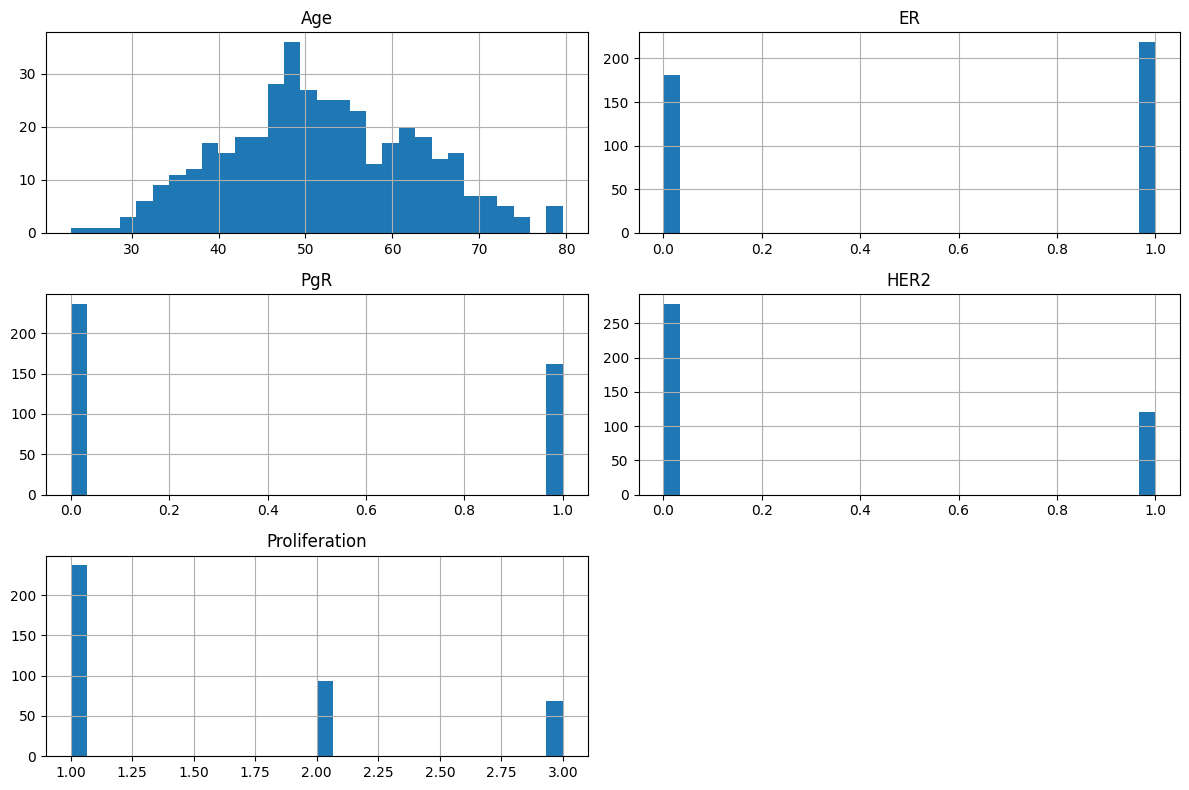

In [23]:
key_cols = ["Age", "ER", "PgR", "HER2", "Proliferation"]
df[key_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


Saved: /content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2/hist_batch_1.png
Saved: /content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2/hist_batch_2.png
Saved: /content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2/hist_batch_3.png
Saved: /content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2/hist_batch_4.png
Saved: /content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2/hist_batch_5.png
Saved: /content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2/hist_batch_6.png
Saved: /content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2/hist_batch_7.png
Saved: /content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2/hist_batch_8.png

All histogram batches saved in folder: /content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2


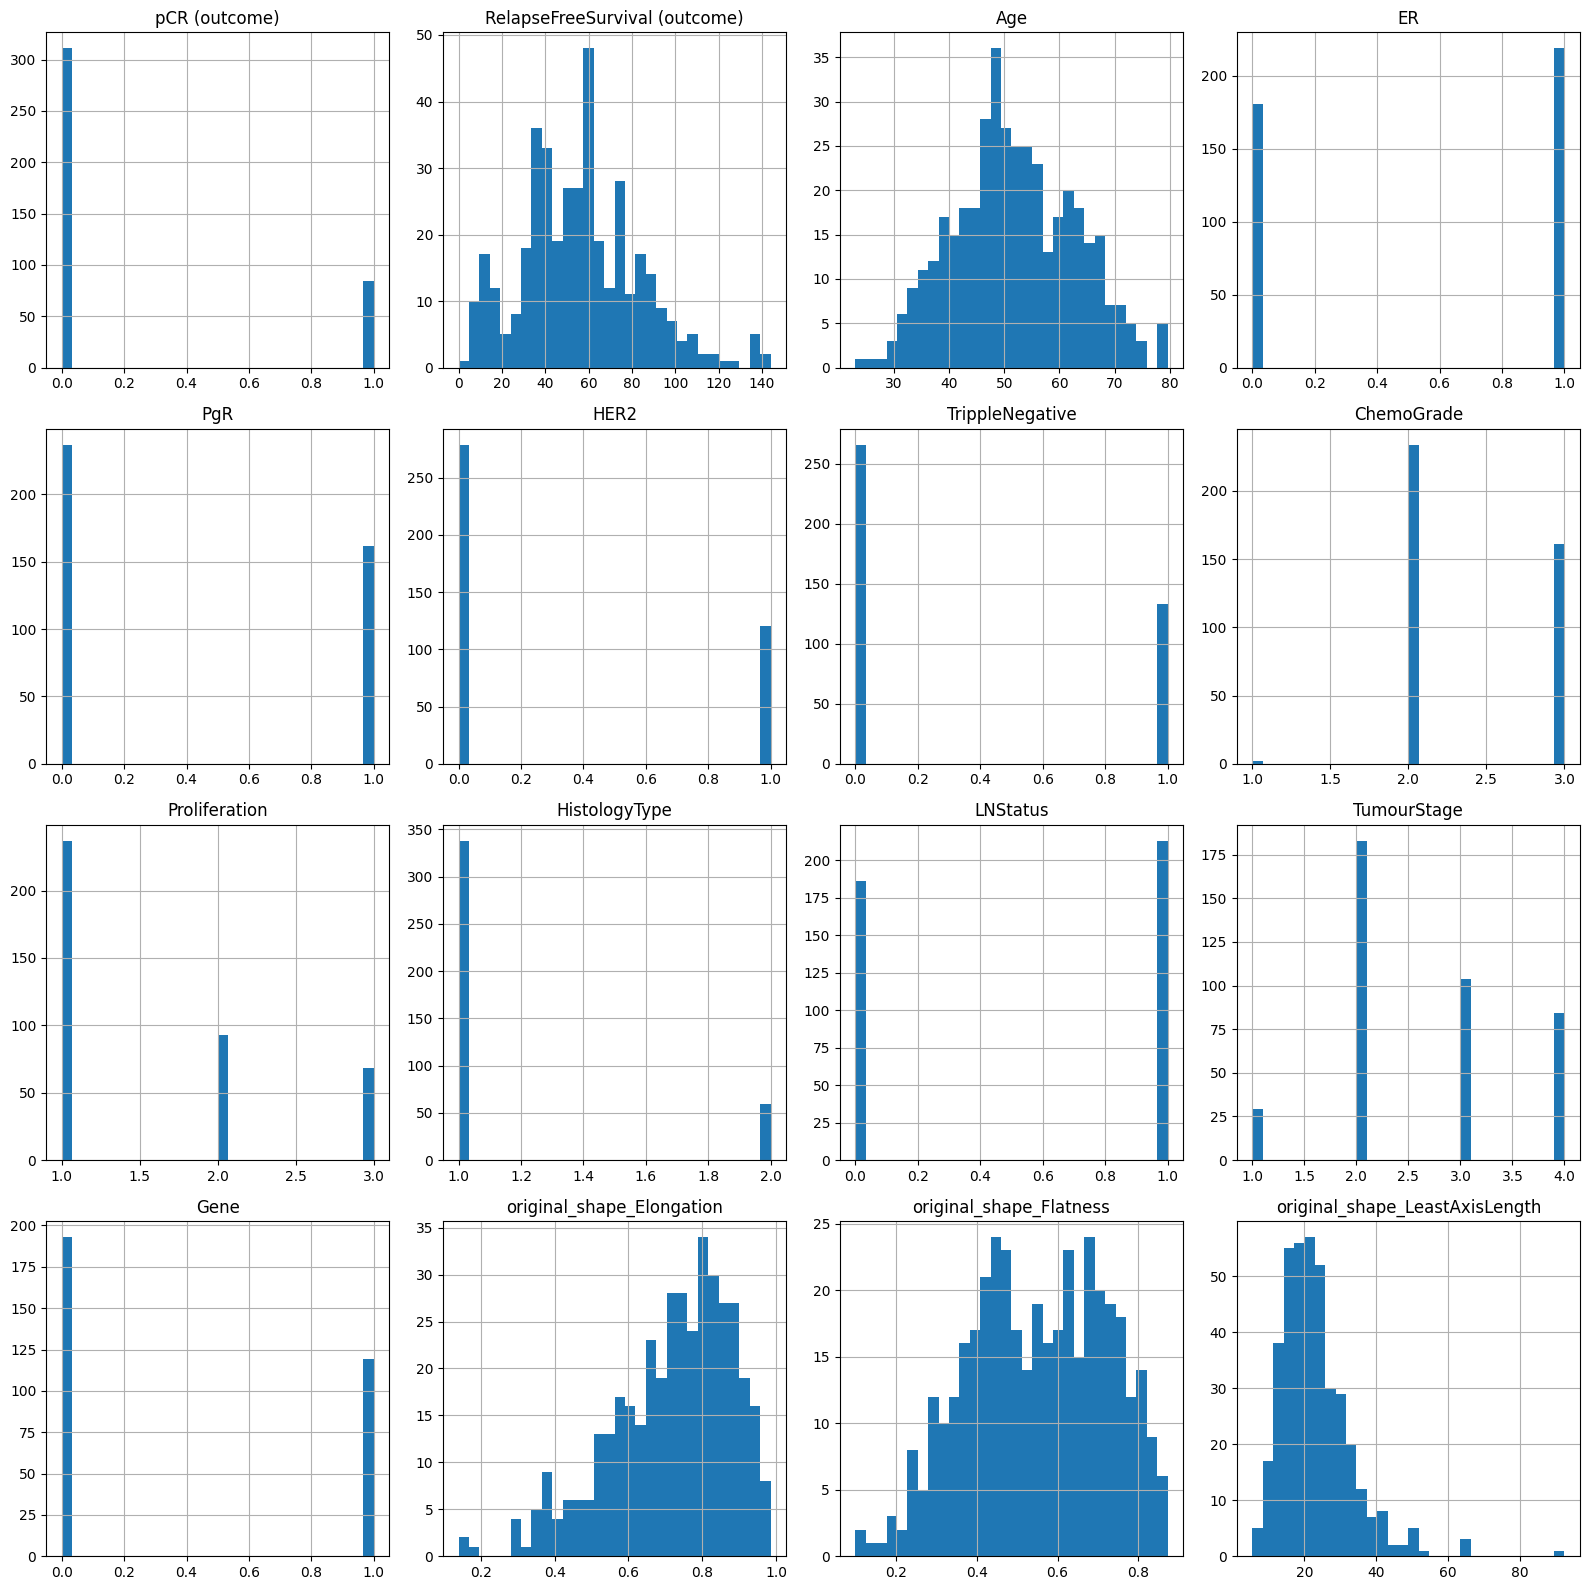

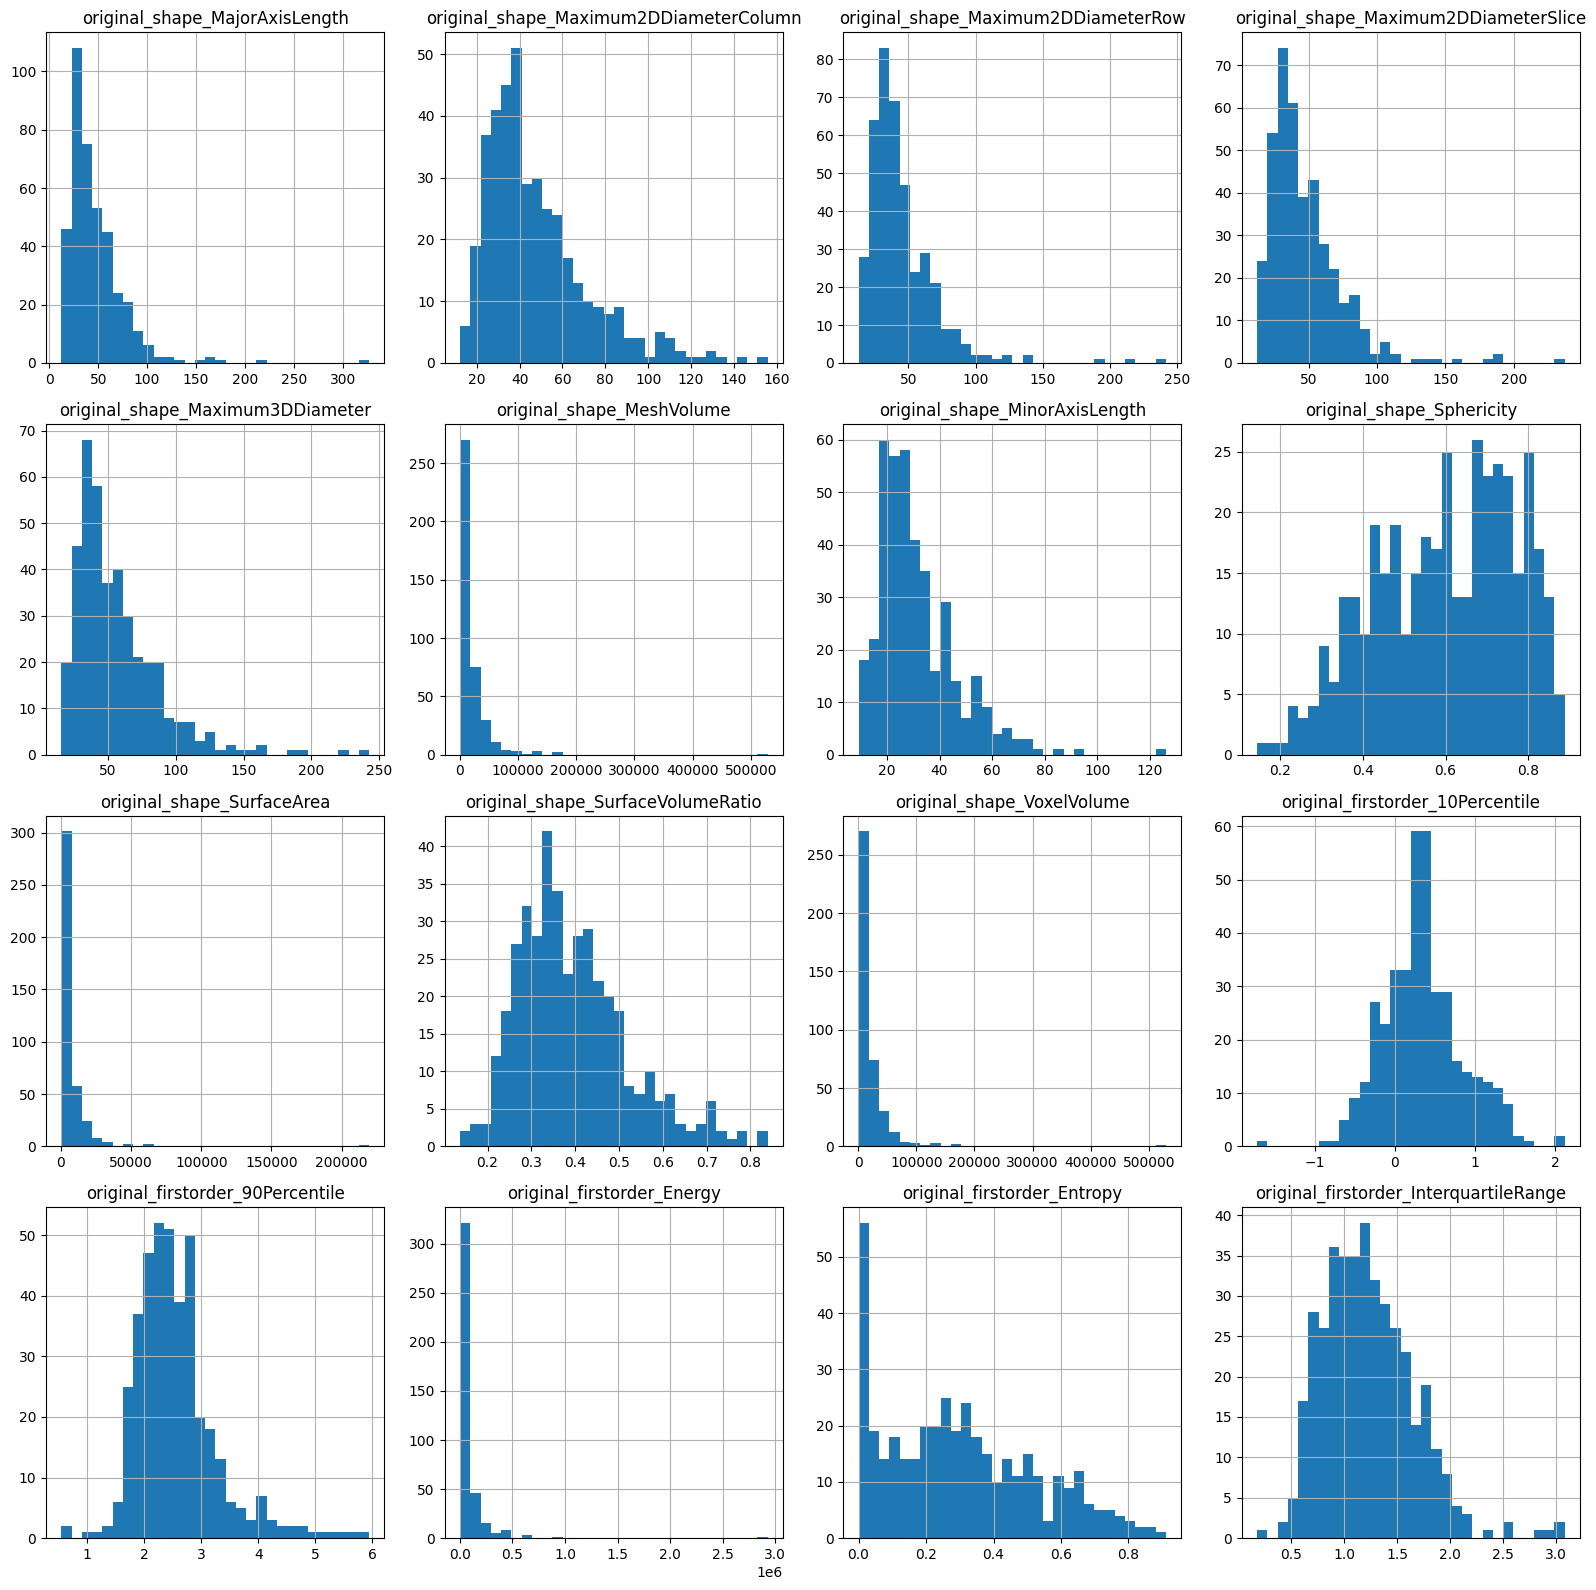

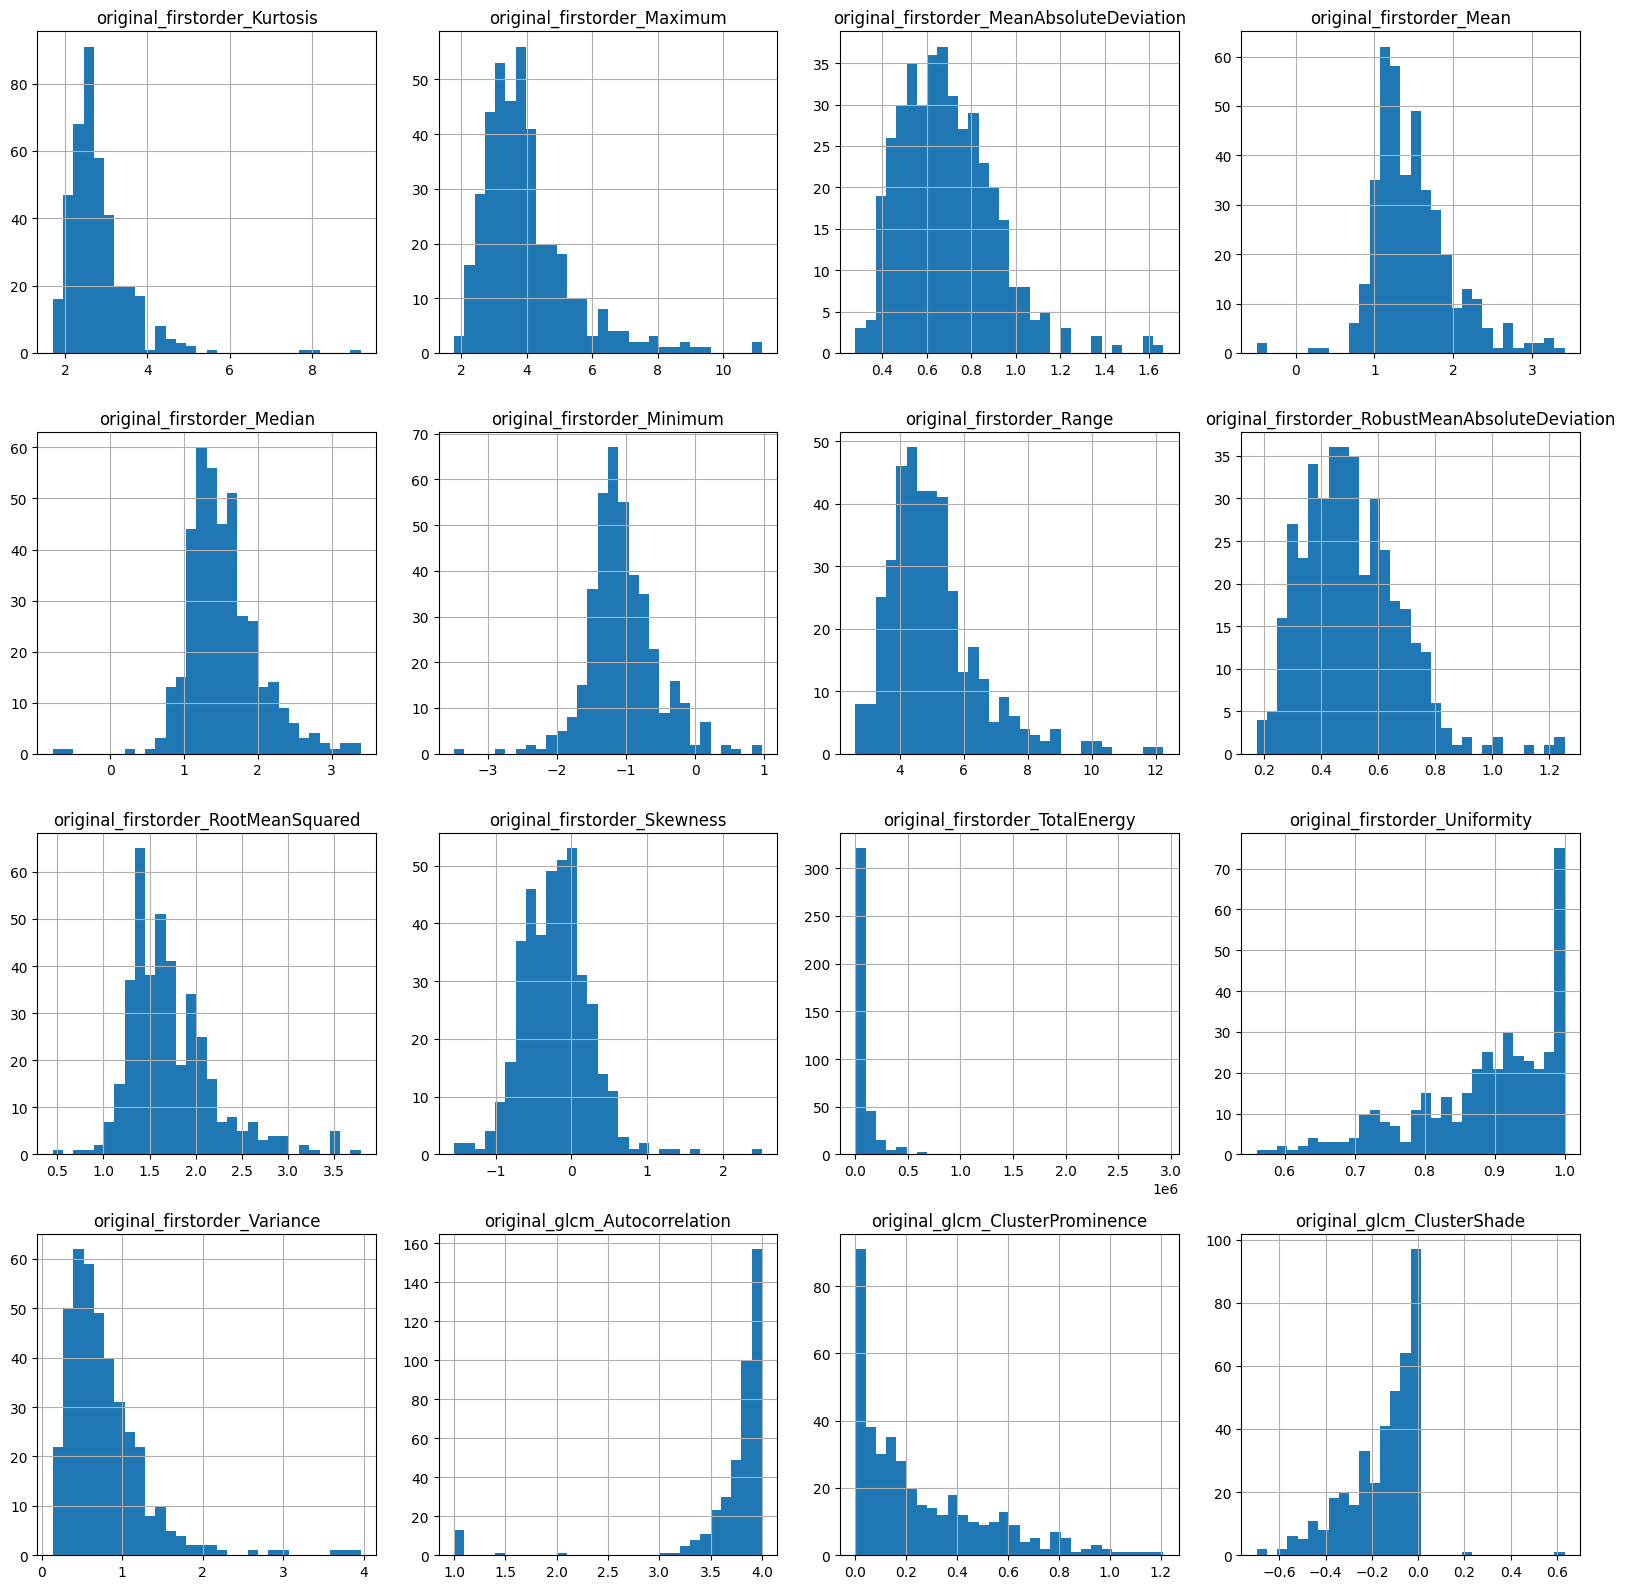

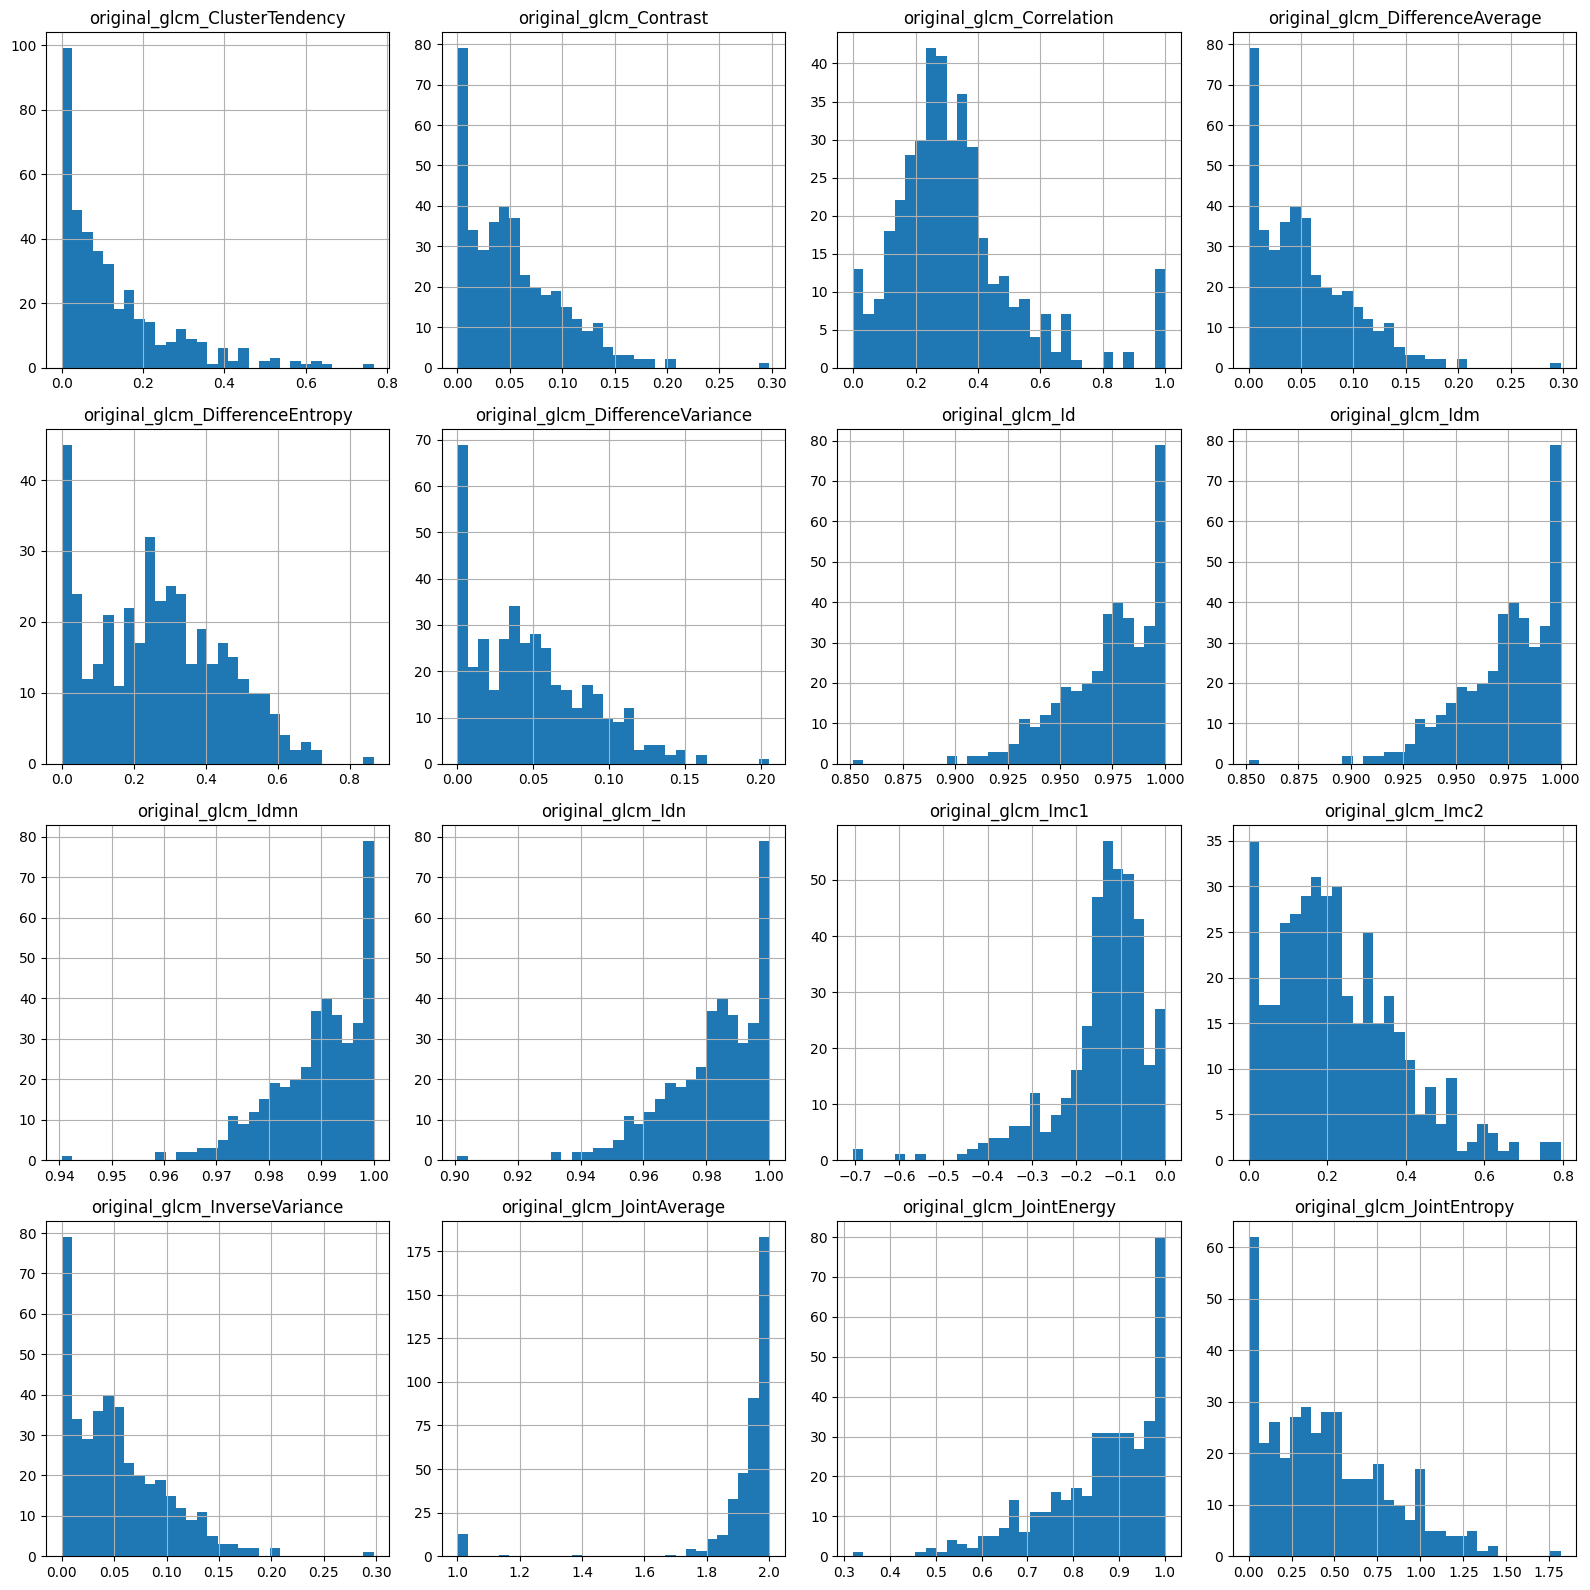

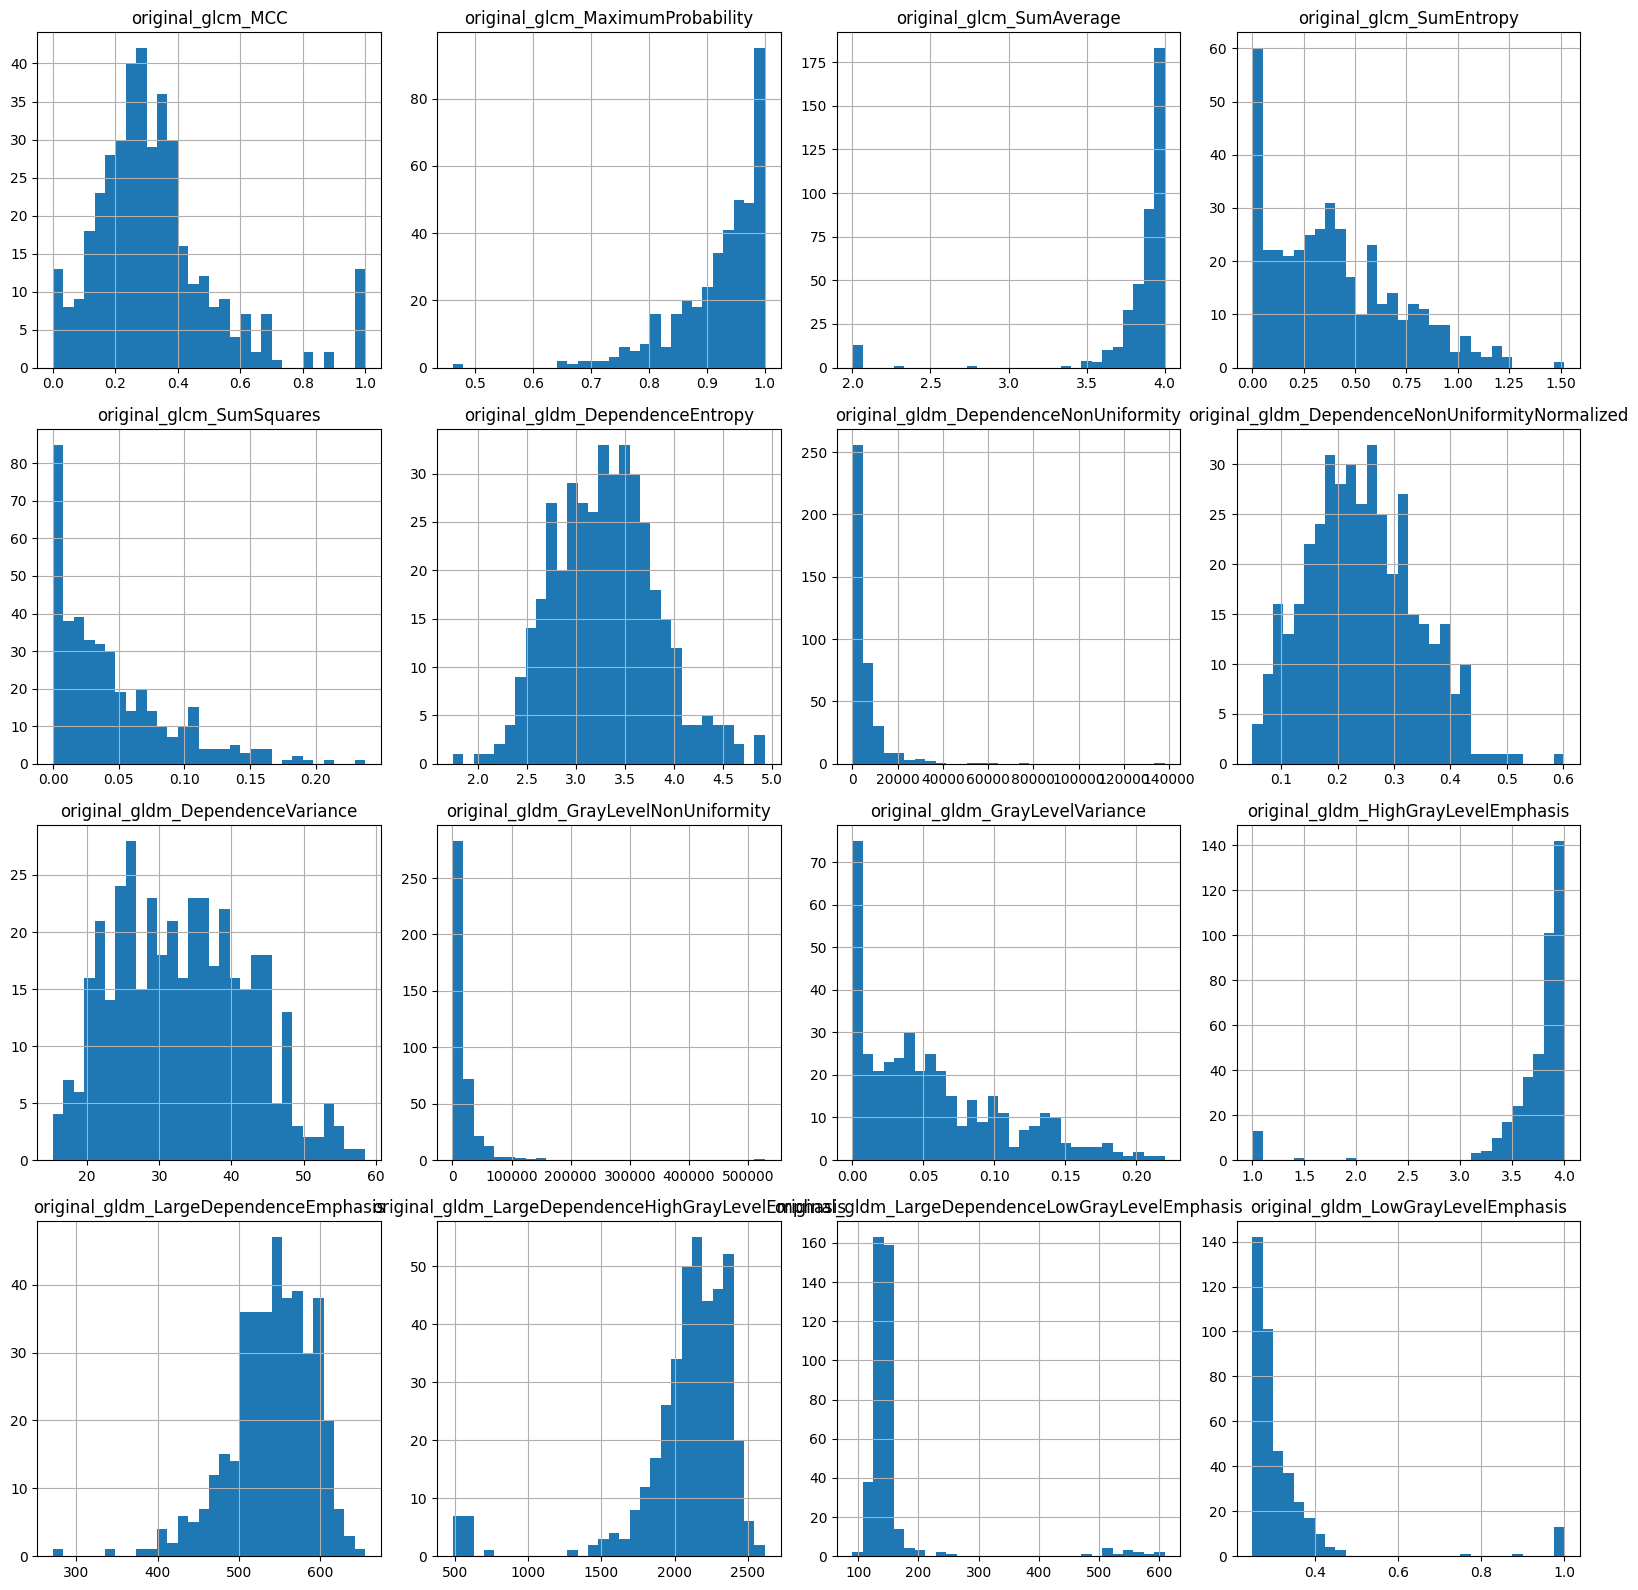

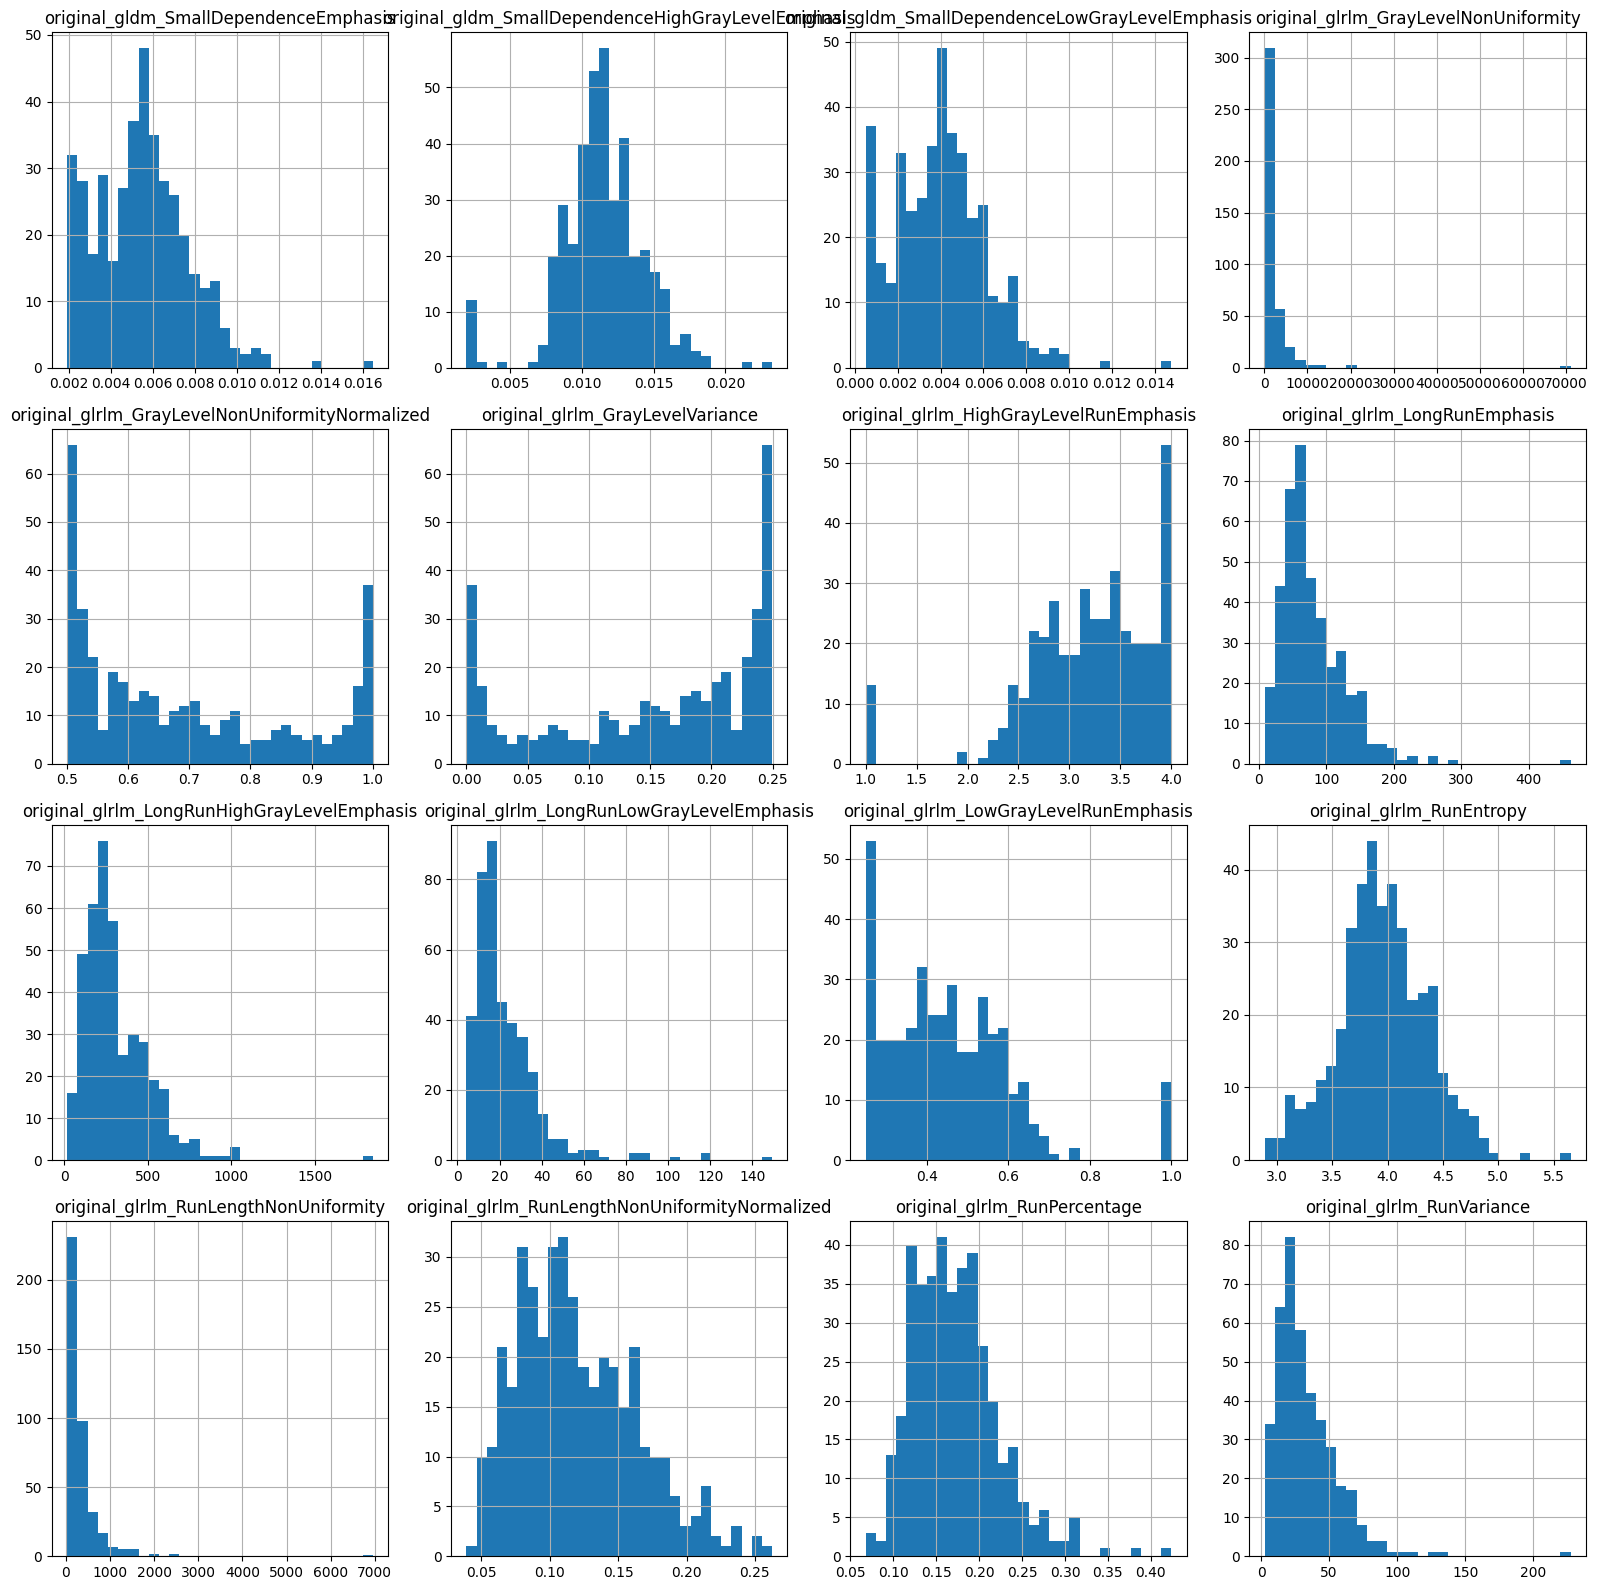

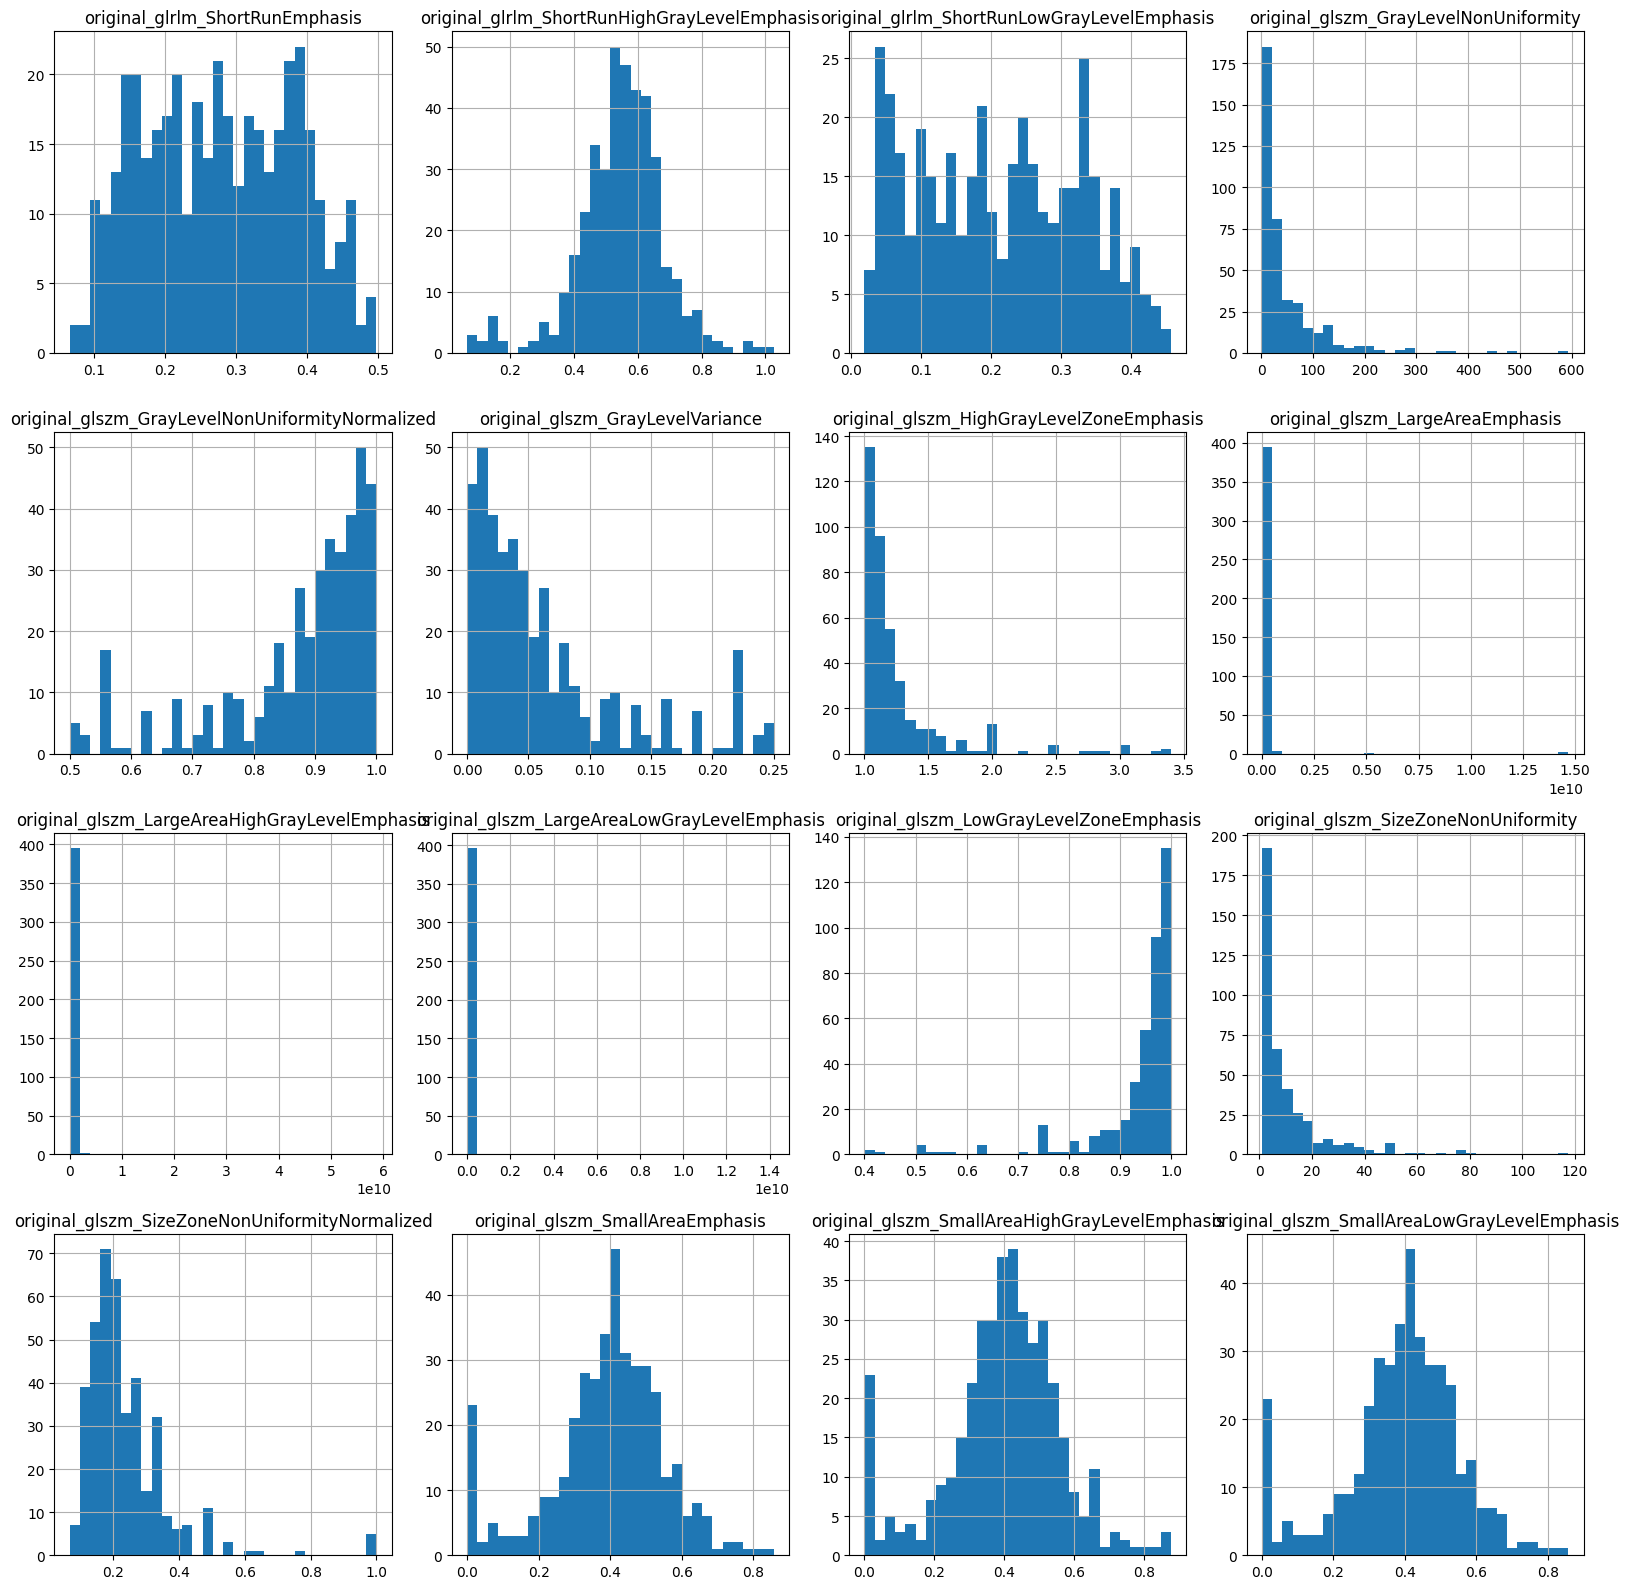

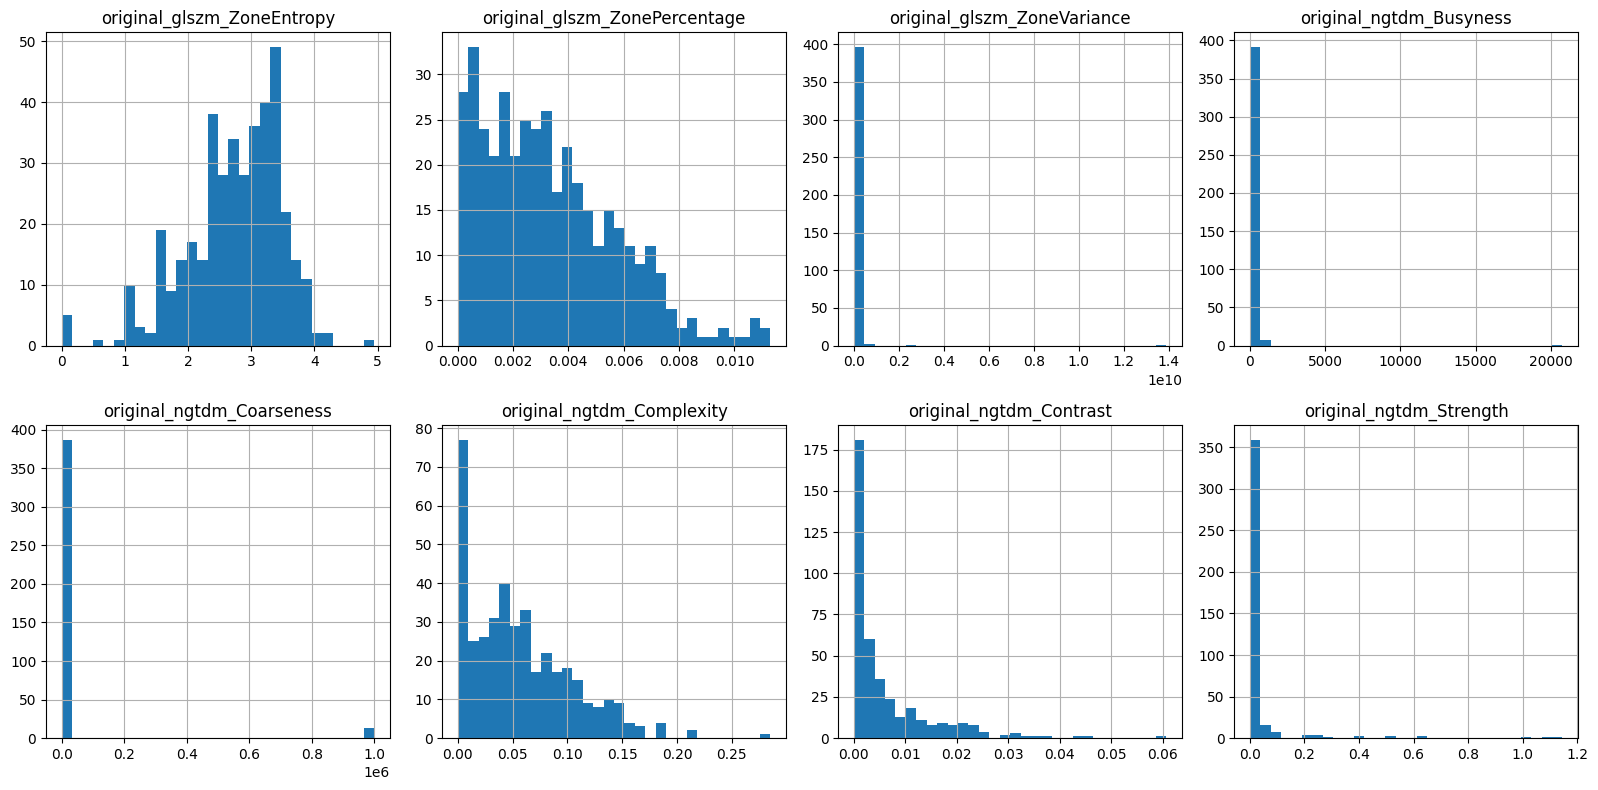

In [24]:
import matplotlib.pyplot as plt
import math
import os

output_dir = "/content/drive/MyDrive/work_2025/Feature Engineering/Histograms/hist2"
os.makedirs(output_dir, exist_ok=True)

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

cols_per_fig = 16
bins = 30

batch_number = 1

for start in range(0, len(num_cols), cols_per_fig):
    subset = num_cols[start:start + cols_per_fig]
    n_cols = 4
    n_rows = math.ceil(len(subset) / n_cols)

    fig = plt.figure(figsize=(16, 4 * n_rows))

    df[subset].hist(
        bins=bins,
        layout=(n_rows, n_cols),
        figsize=(16, 4 * n_rows)
    )

    plt.tight_layout()

    filename = f"{output_dir}/hist_batch_{batch_number}.png"
    plt.savefig(filename, dpi=200)
    plt.close(fig)

    print(f"Saved: {filename}")

    batch_number += 1

print("\nAll histogram batches saved in folder:", output_dir)


In [11]:
target_col = "pCR (outcome)"

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in df.columns. "
                     f"Please update `target_col` accordingly.")

X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature shape:", X.shape, "Target shape:", y.shape)


Feature shape: (400, 120) Target shape: (400,)


In [12]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['RelapseFreeSurvival (outcome)', 'Age', 'ER', 'PgR', 'HER2', 'TrippleNegative', 'ChemoGrade', 'Proliferation', 'HistologyType', 'LNStatus', 'TumourStage', 'Gene', 'original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn', 'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice', 'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength', 'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange', 'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean', 'original_firstorder_Median', 'origi

In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)


In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if y.nunique() < 20 else None
)

print("Train size:", X_train.shape, "Valid size:", X_valid.shape)

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print("Processed train shape:", X_train_processed.shape)
print("Processed valid shape:", X_valid_processed.shape)


Train size: (320, 120) Valid size: (80, 120)
Processed train shape: (320, 439)
Processed valid shape: (80, 439)
